# EEG Hackathon: Text-Based Reasoning for Alzheimer's Disease

> **Goal**: Build a system that analyzes raw EEG and produces *clinician-style* reasoning —
> not just a label, but evidence-linked differential diagnoses with uncertainty handling.

---

## Pipeline Architecture

```
Raw EEG (19 channels × ~300,000 samples per subject)
        │
        ├─── Classical Pipeline ─────────────────────────────────────────────────────────
        │    §7 Preprocessing → §8 Biomarker Extraction → §9 Per-Subject Summary
        │    (PDR, band powers, coherence, LZ complexity — encodes clinical knowledge)
        │
        ├─── Deep Learning Pipeline ─────────────────────────────────────────────────────
        │    §10 EEGConformer Training (5-fold CV)
        │    §11 Integrated Gradients → Attribution Maps (channel × time)
        │    §12 Statistical Validation (Kruskal-Wallis + effect size + permutation test)
        │    §13 Mapping Layer (channel + band → clinical language)
        │
        └─── LLM Reasoning ──────────────────────────────────────────────────────────────
             §14 Claude API — synthesizes both evidence streams into diagnosis + reasoning
```

**Why two pipelines?**
- Classical biomarkers encode 40 years of published EEG literature but have confirmation bias
- The deep model discovers patterns from data — but needs statistical validation to be trusted
- Together, they give the LLM grounded, multi-source evidence to reason from

## Dataset: ds004504
- **88 subjects**: 36 Alzheimer's Disease (AD), 29 Healthy Controls (CN), 23 Frontotemporal Dementia (FTD)
- **19-channel resting-state EEG**, eyes closed, 10–20 system, ~10 minutes @ 500 Hz
    - 19 electrodes placed on the scalp, each recording electrical activity from a different brain region
    - Resting state: subject sits still, not performing any task
    - Eyes closed: reduces eye movement artifacts (blinks, saccades) that can swamp brain signals
    - **10-20 system**: standardized electrode placement — same positions across every lab worldwide
    - **~10 minutes**: long enough to capture stable resting-state brain dynamics
    - **500 Hz**: 500 samples/sec/channel — satisfies Nyquist theorem for frequencies up to 250 Hz
- **BIDS format** with `.set` (EEGLAB) files managed via git-annex

## Notebook Sections
1. [Setup & Installation](#1-setup)
2. [Download Dataset](#2-download)
3. [Load Participant Metadata](#3-metadata)
4. [Load Raw EEG with MNE](#4-load)
5. [Dataset Overview & Visualizations](#5-overview)
6. [Single-Subject EEG Exploration](#6-single)
7. [Preprocessing Pipeline](#7-preprocessing)
8. [Classical Biomarker Extraction](#8-biomarkers)
9. [Per-Subject Biomarker Summary](#9-summary)
10. [Deep EEG Model: EEGConformer](#10-deep-model)
11. [Attribution Maps: Integrated Gradients](#11-attribution)
12. [Statistical Validation of Attribution](#12-stats)
13. [Mapping Layer: Attribution → Clinical Language](#13-mapping)
14. [Faithful LLM Reasoning: Combined Evidence](#14-llm)


In [78]:
# ═══════════════════════════════════════════════════════════════════════════
# UH MANOA BRAND STYLE SYSTEM
# ═══════════════════════════════════════════════════════════════════════════
#
# Colors sourced from the UH Manoa Graphics Standards:
#   https://www.hawaii.edu/offices/communications/standards/graphics-standards/
#
# Typography: Lato (digital) / Arial (print)
# Run this cell first — all diagram cells import from here.

# ── Primary palette ────────────────────────────────────────────────────────
UH_GREEN        = '#007749'   # UH Manoa primary green
UH_GREEN_DARK   = '#005031'   # Deep forest green (borders, footer)
UH_GREEN_LIGHT  = '#e8f4ee'   # Tint for subtle backgrounds

UH_GOLD         = '#b3995d'   # UH Manoa primary gold
UH_GOLD_DARK    = '#907139'   # Deep gold (hover / borders)
UH_GOLD_LIGHT   = '#f7f1e3'   # Gold tint

# ── Neutrals ───────────────────────────────────────────────────────────────
UH_BLACK        = '#1a1a1a'   # Near-black body text
UH_DARK_GRAY    = '#444444'   # Secondary / header text
UH_MID_GRAY     = '#6d6d6d'   # Muted labels
UH_LIGHT_GRAY   = '#f0f0f0'   # Panel backgrounds
UH_WHITE        = '#FFFFFF'

# ── Semantic roles ─────────────────────────────────────────────────────────
# Change these four lines to retheme every diagram in the notebook at once.

COLOR_KEY_OUTPUT  = UH_GREEN        # primary filled boxes (key outputs / models)
COLOR_KEY_BORDER  = UH_GREEN_DARK
COLOR_KEY_TEXT    = UH_WHITE

COLOR_ACCENT      = UH_GOLD         # final output boxes
COLOR_ACCENT_BDR  = UH_GOLD_DARK
COLOR_ACCENT_TEXT = UH_WHITE

COLOR_PROCESS     = UH_WHITE        # processing-step boxes
COLOR_PROCESS_BDR = '#AAAAAA'
COLOR_PROCESS_TXT = UH_BLACK

COLOR_BG          = UH_WHITE        # figure background
COLOR_LABEL       = UH_MID_GRAY     # italic section labels
COLOR_EDGE        = '#555555'       # arrows
COLOR_DIVIDER     = '#DDDDDD'       # dashed section separators
COLOR_FILTER      = UH_LIGHT_GRAY   # funnel icons

# ── draw.io style strings (DIO) ────────────────────────────────────────────
# Use DIO['key_output'] etc. in any draw.io generator cell.

DIO = {
    'key_output': (
        f'rounded=1;whiteSpace=wrap;html=1;arcSize=8;'
        f'fillColor={COLOR_KEY_OUTPUT};fontColor={COLOR_KEY_TEXT};'
        f'strokeColor={COLOR_KEY_BORDER};fontStyle=1;fontSize=10;'
    ),
    'accent': (
        f'rounded=1;whiteSpace=wrap;html=1;arcSize=8;'
        f'fillColor={COLOR_ACCENT};fontColor={COLOR_ACCENT_TEXT};'
        f'strokeColor={COLOR_ACCENT_BDR};fontStyle=1;fontSize=10;'
    ),
    'process': (
        f'rounded=1;whiteSpace=wrap;html=1;arcSize=8;'
        f'fillColor={COLOR_PROCESS};fontColor={COLOR_PROCESS_TXT};'
        f'strokeColor={COLOR_PROCESS_BDR};fontSize=9;'
    ),
    'process_small': (
        f'rounded=1;whiteSpace=wrap;html=1;arcSize=8;'
        f'fillColor={COLOR_PROCESS};fontColor={COLOR_PROCESS_TXT};'
        f'strokeColor={COLOR_PROCESS_BDR};fontSize=8;'
    ),
    'edge_h': (
        'edgeStyle=orthogonalEdgeStyle;rounded=0;orthogonalLoop=1;'
        'jettySize=auto;exitX=1;exitY=0.5;exitDx=0;exitDy=0;'
        f'entryX=0;entryY=0.5;entryDx=0;entryDy=0;strokeColor={COLOR_EDGE};'
    ),
    'edge_d': (
        'edgeStyle=orthogonalEdgeStyle;rounded=0;'
        'exitX=0.5;exitY=1;exitDx=0;exitDy=0;'
        f'entryX=0.5;entryY=0;entryDx=0;entryDy=0;strokeColor={COLOR_EDGE};'
    ),
    'label': (
        'text;html=1;strokeColor=none;fillColor=none;'
        f'align=left;fontSize=9;fontStyle=2;fontColor={COLOR_LABEL};'
    ),
    'title': (
        'text;html=1;strokeColor=none;fillColor=none;'
        f'align=left;fontSize=13;fontStyle=1;fontColor={UH_BLACK};'
    ),
    'funnel': (
        f'shape=mxgraph.flowchart.manual_input;'
        f'fillColor={COLOR_FILTER};strokeColor={COLOR_EDGE};fontSize=8;'
    ),
}

print('UH Manoa style system loaded.')
print(f'  Primary green : {UH_GREEN}')
print(f'  Primary gold  : {UH_GOLD}')
print(f'  Dark gray     : {UH_DARK_GRAY}')
print('  DIO keys      :', list(DIO.keys()))


UH Manoa style system loaded.
  Primary green : #007749
  Primary gold  : #b3995d
  Dark gray     : #444444
  DIO keys      : ['key_output', 'accent', 'process', 'process_small', 'edge_h', 'edge_d', 'label', 'title', 'funnel']


## Architecture Diagram

Two rendering options:
- **Cell below**: inline `matplotlib` diagram — renders in notebook, export as PNG
- **Cell after**: generates `eeg_architecture.drawio` — open in [draw.io desktop](https://github.com/jgraph/drawio-desktop/releases) or [app.diagrams.net](https://app.diagrams.net) for full editing


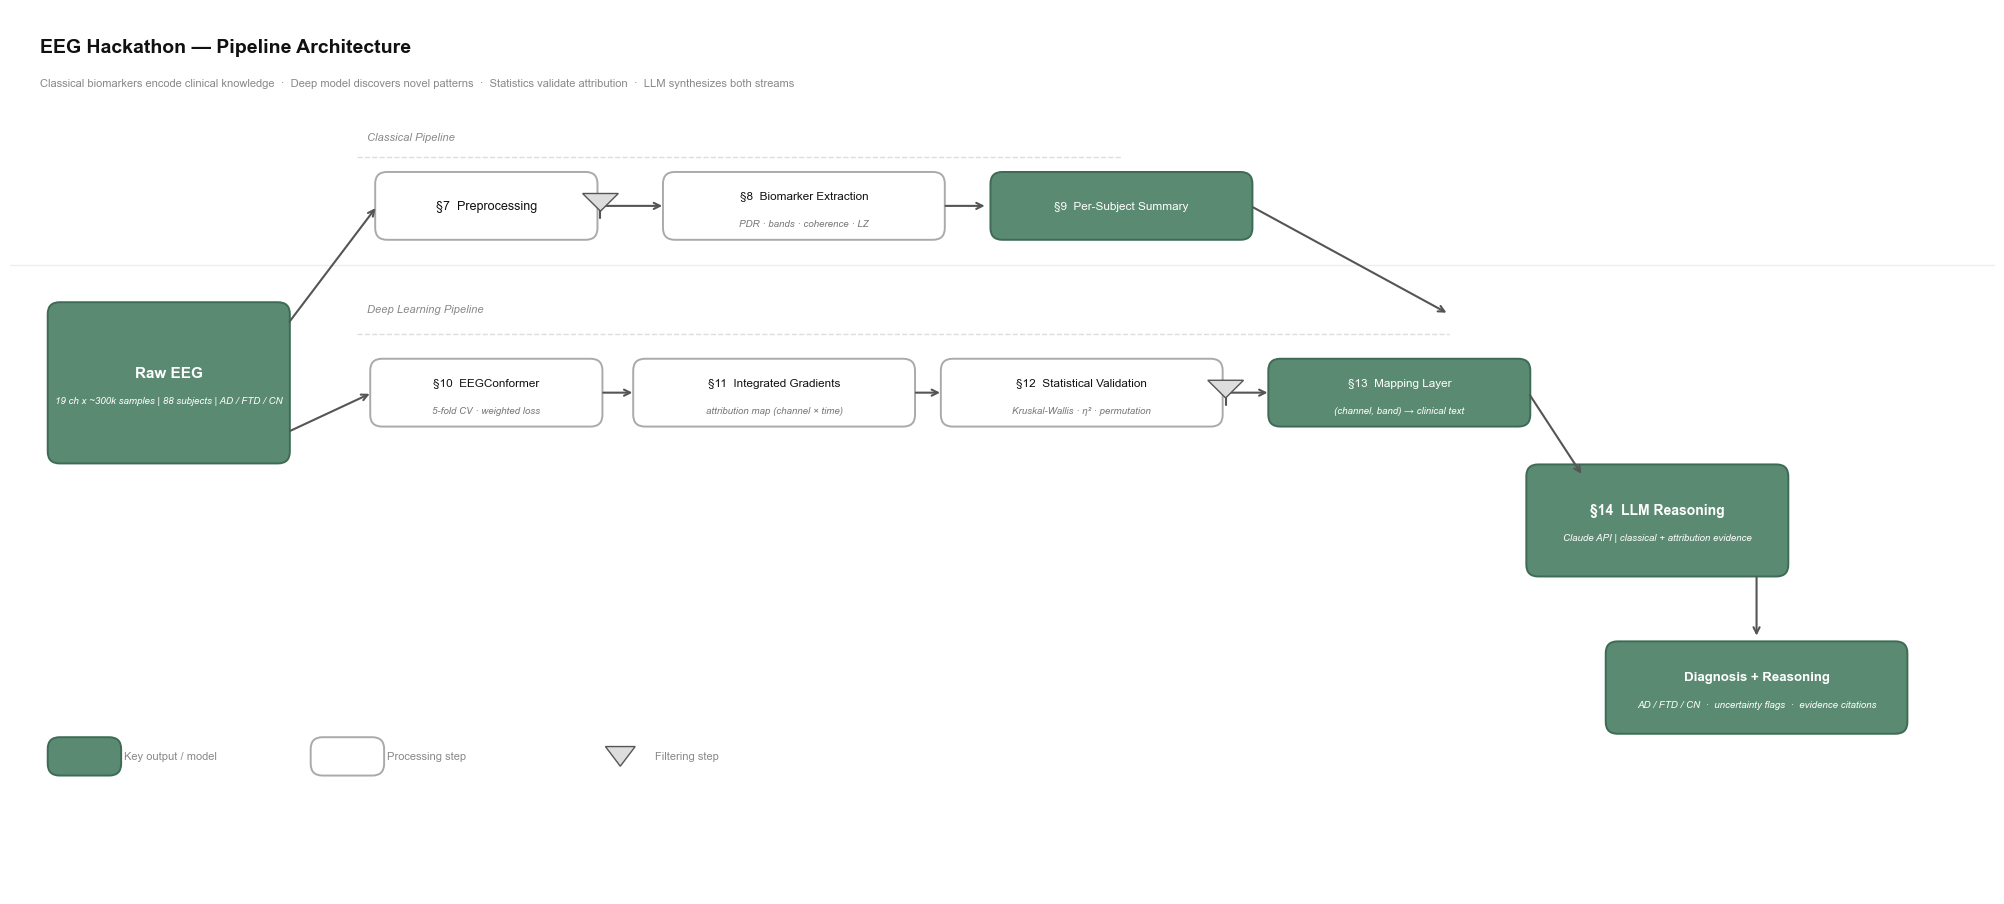

Saved: architecture_diagram.png


In [79]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.path import Path
import matplotlib.patheffects as pe

GREEN       = '#5B8A72'
GREEN_DARK  = '#3d6b56'
WHITE       = '#FFFFFF'
BLACK       = '#111111'
GRAY        = '#888888'
LIGHT       = '#F7F7F7'

fig, ax = plt.subplots(figsize=(20, 9))
ax.set_xlim(0, 20)
ax.set_ylim(0, 9)
ax.axis('off')
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

def box(x, y, w, h, label, fill=WHITE, fontsize=9, bold=False,
        sub=None, text_col=None):
    if text_col is None:
        text_col = WHITE if fill == GREEN else BLACK
    r = 0.12
    patch = FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle=f"round,pad=0.02,rounding_size={r}",
        facecolor=fill,
        edgecolor=GREEN_DARK if fill == GREEN else '#AAAAAA',
        linewidth=1.4, zorder=3
    )
    ax.add_patch(patch)
    yo = y + 0.1 if sub else y
    ax.text(x, yo, label, ha='center', va='center', fontsize=fontsize,
            color=text_col, fontweight='bold' if bold else 'normal', zorder=4)
    if sub:
        ax.text(x, y - 0.18, sub, ha='center', va='center', fontsize=7,
                color=WHITE if fill == GREEN else '#777777',
                style='italic', zorder=4)

def arrow(x0, y0, x1, y1, bend=0.0):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(
                    arrowstyle='->', color='#555555', lw=1.5,
                    connectionstyle=f'arc3,rad={bend}'),
                zorder=5)

def funnel(x, y, sz=0.18):
    tri = plt.Polygon(
        [[x - sz, y + sz*0.7], [x + sz, y + sz*0.7], [x, y - sz*0.3]],
        closed=True, facecolor='#DDDDDD', edgecolor='#555555',
        linewidth=1.0, zorder=6)
    ax.add_patch(tri)
    ax.plot([x, x], [y - sz*0.3, y - sz*0.7],
            color='#555555', lw=1.5, zorder=6)

def section_label(x, y, text):
    ax.text(x, y, text, ha='left', va='center', fontsize=8,
            color=GRAY, style='italic')

# ── Title ─────────────────────────────────────────────────────────────────
ax.text(0.3, 8.7, 'EEG Hackathon — Pipeline Architecture',
        fontsize=14, fontweight='bold', color=BLACK, va='top')
ax.text(0.3, 8.3,
        'Classical biomarkers encode clinical knowledge  '
        '·  Deep model discovers novel patterns  '
        '·  Statistics validate attribution  '
        '·  LLM synthesizes both streams',
        fontsize=8, color=GRAY, va='top')

# ── INPUT ─────────────────────────────────────────────────────────────────
box(1.6, 5.2, 2.4, 1.6, 'Raw EEG', fill=GREEN,
    fontsize=11, bold=True,
    sub='19 ch x ~300k samples | 88 subjects | AD / FTD / CN')

# ── CLASSICAL PIPELINE ─────────────────────────────────────────────────────
section_label(3.6, 7.7, 'Classical Pipeline')
ax.plot([3.5, 11.2], [7.5, 7.5], color='#DDDDDD', lw=1, ls='--', zorder=1)

box(4.8, 7.0, 2.2, 0.65, '§7  Preprocessing', fontsize=9)
funnel(5.95, 7.0)

box(8.0, 7.0, 2.8, 0.65, '§8  Biomarker Extraction',
    fontsize=8.5, sub='PDR · bands · coherence · LZ')

box(11.2, 7.0, 2.6, 0.65, '§9  Per-Subject Summary',
    fill=GREEN, fontsize=8.5)

arrow(2.8, 5.8, 3.7, 7.0)
arrow(5.9, 7.0, 6.6, 7.0)
arrow(9.4, 7.0, 9.85, 7.0)
arrow(12.5, 7.0, 14.5, 5.9)

# ── DEEP PIPELINE ──────────────────────────────────────────────────────────
section_label(3.6, 5.95, 'Deep Learning Pipeline')
ax.plot([3.5, 14.5], [5.7, 5.7], color='#DDDDDD', lw=1, ls='--', zorder=1)

box(4.8, 5.1, 2.3, 0.65, '§10  EEGConformer',
    fontsize=8.5, sub='5-fold CV · weighted loss')

box(7.7, 5.1, 2.8, 0.65, '§11  Integrated Gradients',
    fontsize=8.5, sub='attribution map (channel × time)')

box(10.8, 5.1, 2.8, 0.65, '§12  Statistical Validation',
    fontsize=8.5, sub='Kruskal-Wallis · η² · permutation')
funnel(12.25, 5.1)

box(14.0, 5.1, 2.6, 0.65, '§13  Mapping Layer',
    fill=GREEN, fontsize=8.5, sub='(channel, band) → clinical text')

arrow(2.8, 4.7, 3.65, 5.1)
arrow(5.95, 5.1, 6.3, 5.1)
arrow(9.1, 5.1, 9.4, 5.1)
arrow(12.2, 5.1, 12.7, 5.1)
arrow(15.3, 5.1, 15.85, 4.25)

# ── LLM REASONING ──────────────────────────────────────────────────────────
box(16.6, 3.8, 2.6, 1.1, '§14  LLM Reasoning',
    fill=GREEN, fontsize=10, bold=True,
    sub='Claude API | classical + attribution evidence')

arrow(17.6, 3.25, 17.6, 2.6)

box(17.6, 2.1, 3.0, 0.9, 'Diagnosis + Reasoning',
    fill=GREEN, fontsize=9.5, bold=True,
    sub='AD / FTD / CN  ·  uncertainty flags  ·  evidence citations')

# ── CURLY BRACE dividers ───────────────────────────────────────────────────
for y_line in [6.4]:
    ax.axhline(y_line, color='#EEEEEE', lw=1.0, zorder=0)

# ── LEGEND ────────────────────────────────────────────────────────────────
lx, ly = 0.4, 1.4
box(lx + 0.35, ly, 0.7, 0.35, '', fill=GREEN)
ax.text(lx + 0.75, ly, 'Key output / model', va='center', fontsize=8, color=GRAY)

box(lx + 3.0, ly, 0.7, 0.35, '', fill=WHITE)
ax.text(lx + 3.4, ly, 'Processing step', va='center', fontsize=8, color=GRAY)

tri_demo = plt.Polygon(
    [[lx + 5.6, ly + 0.1], [lx + 5.9, ly + 0.1], [lx + 5.75, ly - 0.1]],
    closed=True, facecolor='#DDDDDD', edgecolor='#555555', lw=1.0)
ax.add_patch(tri_demo)
ax.text(lx + 6.1, ly, 'Filtering step', va='center', fontsize=8, color=GRAY)

plt.tight_layout(pad=0.5)
plt.savefig('../data/architecture_diagram.png', dpi=180, bbox_inches='tight',
            facecolor=WHITE)
plt.show()
print('Saved: architecture_diagram.png')


In [80]:
# ── Generate draw.io (.drawio) file ─────────────────────────────────────
#
# Opens in draw.io desktop or https://app.diagrams.net
# File → Open from → Device → select eeg_architecture.drawio

GREEN_S = ('rounded=1;whiteSpace=wrap;html=1;'
           'fillColor=#5B8A72;fontColor=#FFFFFF;'
           'strokeColor=#3d6b56;fontStyle=1;fontSize=10;')
WHITE_S = ('rounded=1;whiteSpace=wrap;html=1;'
           'fillColor=#FFFFFF;strokeColor=#AAAAAA;fontSize=9;')
SMALL_S = ('rounded=1;whiteSpace=wrap;html=1;'
           'fillColor=#FFFFFF;strokeColor=#AAAAAA;fontSize=8;')
EDGE_H  = ('edgeStyle=orthogonalEdgeStyle;rounded=0;'
           'orthogonalLoop=1;jettySize=auto;'
           'exitX=1;exitY=0.5;exitDx=0;exitDy=0;'
           'entryX=0;entryY=0.5;entryDx=0;entryDy=0;')
EDGE_D  = ('edgeStyle=orthogonalEdgeStyle;rounded=0;'
           'exitX=0.5;exitY=1;exitDx=0;exitDy=0;'
           'entryX=0.5;entryY=0;entryDx=0;entryDy=0;')
LABEL_S = ('text;html=1;strokeColor=none;fillColor=none;'
           'align=left;fontSize=9;fontStyle=2;fontColor=#888888;')
TITLE_S = ('text;html=1;strokeColor=none;fillColor=none;'
           'align=left;fontSize=13;fontStyle=1;')
FUNNEL_S= ('shape=mxgraph.flowchart.manual_input;'
           'fillColor=#DDDDDD;strokeColor=#555555;fontSize=8;')

cells = []
_cid = [2]

def nid():
    _cid[0] += 1
    return str(_cid[0])

def vertex(label, style, x, y, w, h):
    cid = nid()
    cells.append(
        f'<mxCell id="{cid}" value="{label}" style="{style}" '
        f'vertex="1" parent="1">'
        f'<mxGeometry x="{x}" y="{y}" width="{w}" height="{h}" '
        f'as="geometry"/></mxCell>')
    return cid

def connect(src, tgt, style=EDGE_H):
    cid = nid()
    cells.append(
        f'<mxCell id="{cid}" value="" style="{style}" '
        f'edge="1" source="{src}" target="{tgt}" parent="1">'
        f'<mxGeometry relative="1" as="geometry"/></mxCell>')

BW, BH = 175, 55
# ── Input
raw = vertex('Raw EEG&#xa;19 ch × ~300k samples&#xa;88 subjects (AD/FTD/CN)',
             GREEN_S, 20, 145, 155, 75)

# ── Classical pipeline (y=120)
vertex('Classical Pipeline', LABEL_S, 210, 90, 180, 22)
pre  = vertex('§7  Preprocessing',       WHITE_S, 210, 115, BW, BH)
bio  = vertex('§8  Biomarker Extraction&#xa;PDR · bands · coherence · LZ',
              SMALL_S, 420, 115, BW, BH)
summ = vertex('§9  Per-Subject Summary', GREEN_S, 630, 115, BW, BH)
connect(raw, pre); connect(pre, bio); connect(bio, summ)

# ── Deep pipeline (y=240)
vertex('Deep Learning Pipeline', LABEL_S, 210, 210, 200, 22)
conf = vertex('§10  EEGConformer&#xa;5-fold CV · weighted loss',
              SMALL_S, 210, 235, BW, BH)
ig   = vertex('§11  Integrated Gradients&#xa;attribution (channel × time)',
              SMALL_S, 420, 235, BW, BH)
stat = vertex('§12  Statistical Validation&#xa;Kruskal · η² · permutation',
              SMALL_S, 630, 235, BW, BH)
mapp = vertex('§13  Mapping Layer&#xa;(channel, band) → clinical text',
              GREEN_S, 840, 235, BW, BH)
connect(raw, conf); connect(conf, ig); connect(ig, stat)
connect(stat, mapp)

# ── Funnels
vertex('⊿', FUNNEL_S, 392, 127, 22, 28)
vertex('⊿', FUNNEL_S, 812, 247, 22, 28)
vertex('⊿', FUNNEL_S, 1048, 162, 22, 28)

# ── LLM + output
llm = vertex('§14  LLM Reasoning&#xa;Claude API',
             GREEN_S, 1075, 145, BW, 75)
out = vertex('Diagnosis + Reasoning&#xa;AD / FTD / CN + uncertainty flags',
             GREEN_S, 1075, 290, BW, 60)

# classical → LLM, mapping → LLM
connect(summ, llm)
connect(mapp, llm)
connect(llm, out, EDGE_D)

# ── Title
vertex('EEG Hackathon — Pipeline Architecture', TITLE_S, 20, 20, 600, 30)

xml = '<?xml version="1.0" encoding="UTF-8"?>\n'
xml += '<mxfile host="app.diagrams.net">\n'
xml += '  <diagram name="EEG Architecture">\n'
xml += ('    <mxGraphModel dx="1400" dy="600" grid="0" gridSize="10" '
        'guides="1" tooltips="1" connect="1" arrows="1" fold="1" '
        'page="0" pageScale="1" pageWidth="1500" pageHeight="500" '
        'math="0" shadow="0">\n')
xml += '      <root>\n'
xml += '        <mxCell id="0"/>\n'
xml += '        <mxCell id="1" parent="0"/>\n'
for c in cells:
    xml += f'        {c}\n'
xml += '      </root>\n'
xml += '    </mxGraphModel>\n'
xml += '  </diagram>\n'
xml += '</mxfile>\n'

out_path = '../data/eeg_architecture.drawio'
with open(out_path, 'w') as f:
    f.write(xml)

print(f'Saved: {out_path}')
print()
print('To open in draw.io:')
print('  Desktop app: File → Open → eeg_architecture.drawio')
print('  Web:         https://app.diagrams.net → File → Open from → Device')
print()
print('The file is plain XML — you can also inspect/edit it in any text editor.')


Saved: ../eeg_architecture.drawio

To open in draw.io:
  Desktop app: File → Open → eeg_architecture.drawio
  Web:         https://app.diagrams.net → File → Open from → Device

The file is plain XML — you can also inspect/edit it in any text editor.


## 1. Setup & Installation <a id='1-setup'></a>

Run this cell once. Restart the kernel after installation if prompted.

In [81]:
import subprocess, sys

packages = [
    'mne>=1.6',          # EEG I/O, filtering, referencing, montage
    'braindecode>=1.2',  # windowed dataset, deep learning helpers
    'captum',            # attribution methods (Integrated Gradients)
    'anthropic',         # Claude API for LLM reasoning stage
    'mne-bids',          # BIDS-format EEG loading
    'matplotlib',
    'seaborn',
    'scipy',
    'pandas',
    'numpy',
    'antropy',           # entropy metrics (Lempel-Ziv, approximate entropy)
    'tqdm',
    'wandb',             # Weights & Biases experiment tracking
    'transformers',      # HuggingFace Transformers (for Stage 2 LLM)
    'torch',             # PyTorch backend
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

print("Installation complete. Restart the kernel if this is your first run.")


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas 3.0.1 requires numpy>=2.3.3; python_version >= "3.14", but you have numpy 1.26.4 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
captum 0.8.0 requires numpy<2.0, but you have numpy 2.4.4 which is incompatible.


Installation complete. Restart the kernel if this is your first run.


In [82]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors     # ← correct namespace for ListedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from scipy import signal, stats
from scipy.signal import coherence, welch

import mne
mne.set_log_level('WARNING')
warnings.filterwarnings('ignore')

import braindecode
from braindecode.datasets import RawDataset, BaseConcatDataset
from braindecode.preprocessing import (
    preprocess, Preprocessor,
    create_fixed_length_windows,
)

print(f'MNE version:         {mne.__version__}')
print(f'braindecode version: {braindecode.__version__}')

# ── Plotting style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')

# ── Group colour palette (used throughout) ──────────────────────────────────────
GROUP_COLORS = {'AD': '#E74C3C', 'FTD': '#F39C12', 'CN': '#2ECC71'}


MNE version:         1.11.0
braindecode version: 1.3.2


## 2. Download Dataset <a id='2-download'></a>

The **ds004504** dataset uses **git-annex** to store large EEG files in S3.  
You need `git` and `git-annex` installed on your system.

- **macOS**: `brew install git-annex`  
- **Linux**: `sudo apt install git-annex`  
- **Windows**: use WSL2 with the Linux instructions

The full download is ~5.4 GB and takes several minutes on a typical connection.  
If you already have the data folder, the download step is skipped automatically.


In [83]:
# Configure dataset path — works whether the kernel starts from repo root or notebooks/
dataset_root_candidates = [Path('data/ds004504'), Path('../data/ds004504')]
existing = next((p for p in dataset_root_candidates if p.exists()), dataset_root_candidates[0])
DATASET_ROOT = existing.resolve()
print(f'Dataset path: {DATASET_ROOT}')


Dataset path: /Users/michaelburiek/Documents/GitHub/eeg_hackathon/data/ds004504


In [84]:
# Step 1: Clone the git repository (creates placeholder symlinks)
import subprocess

if not DATASET_ROOT.exists():
    DATASET_ROOT.parent.mkdir(parents=True, exist_ok=True)
    print('Cloning dataset repository...')
    result = subprocess.run(
        ['git', 'clone', 'https://github.com/OpenNeuroDatasets/ds004504.git', str(DATASET_ROOT)],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        raise RuntimeError(result.stderr.strip() or 'git clone failed')
    print(result.stdout or 'Clone complete.')
else:
    print(f'Repository already exists at {DATASET_ROOT}')


Repository already exists at /Users/michaelburiek/Documents/GitHub/eeg_hackathon/data/ds004504


In [85]:
# Step 2: Download actual EEG payloads via git-annex (skipped if already present)
import shutil, subprocess as sp
from tqdm.auto import tqdm as tqdm_auto

def _run(cmd, **kw):
    return sp.run(cmd, cwd=str(DATASET_ROOT), capture_output=True, text=True, **kw)

# Determine which subjects still need downloading
participants_file = DATASET_ROOT / 'participants.tsv'
if participants_file.exists():
    all_subs = sorted(pd.read_csv(participants_file, sep='\t')['participant_id'].tolist())
else:
    all_subs = sorted([d.name for d in DATASET_ROOT.iterdir()
                       if d.is_dir() and d.name.startswith('sub-')])

def _eeg_path(sub):
    return DATASET_ROOT / sub / 'eeg' / f'{sub}_task-eyesclosed_eeg.set'

missing = [s for s in all_subs if not _eeg_path(s).exists()]

if not missing:
    print(f'All {len(all_subs)} EEG files already present. Skipping download.')
elif shutil.which('git-annex') is None:
    raise RuntimeError(
        'git-annex is not installed.\n'
        '  macOS:  brew install git-annex\n'
        '  Linux:  sudo apt install git-annex\n'
        'Install it, then rerun this cell.'
    )
else:
    _run(['git', 'config', 'annex.dbdir', '/tmp/git-annex-ds004504'])
    _run(['git', 'annex', 'init'])
    _run(['git', 'annex', 'enableremote', 's3-PUBLIC'])

    print(f'Downloading {len(missing)} missing subjects...')
    failed = []
    for sub in tqdm_auto(missing, desc='EEG .set files', unit='subject'):
        r = _run(['git', 'annex', 'get', str(_eeg_path(sub).relative_to(DATASET_ROOT))])
        if r.returncode != 0:
            failed.append((sub, r.stderr.strip()[:120]))

    n_ok = sum(_eeg_path(s).exists() for s in all_subs)
    print(f'Downloaded: {n_ok}/{len(all_subs)}')
    if failed:
        for s, e in failed[:5]:
            print(f'  FAILED {s}: {e}')
        raise RuntimeError(f'{len(failed)} subject(s) failed to download.')


All 88 EEG files already present. Skipping download.


In [86]:
# Verify dataset — identify which subjects have usable EEG files
subjects = sorted([d.name for d in DATASET_ROOT.iterdir()
                   if d.is_dir() and d.name.startswith('sub-')])

available_subjects = [s for s in subjects if _eeg_path(s).exists()]
missing_subjects   = [s for s in subjects if s not in set(available_subjects)]

print(f'Subject folders found:    {len(subjects)}')
print(f'EEG files available:      {len(available_subjects)}')
if missing_subjects:
    print(f'Missing payloads ({len(missing_subjects)}):  {missing_subjects[:5]}...')

if not available_subjects:
    raise RuntimeError('No EEG .set files found. Run the download cell above.')

sample = _eeg_path(available_subjects[0])
print(f'\nSample file: {sample.name}')
print(f'File size:   {sample.stat().st_size / 1e6:.1f} MB')


Subject folders found:    88
EEG files available:      88

Sample file: sub-001_task-eyesclosed_eeg.set
File size:   24.0 MB


## 3. Load Participant Metadata <a id='3-metadata'></a>

The `participants.tsv` BIDS file gives us group labels, MMSE scores, and demographics.

| Column | Meaning |
|---|---|
| `Group` | A=Alzheimer's (AD), C=Control (CN), F=Frontotemporal Dementia (FTD) |
| `MMSE` | Mini-Mental State Exam (0=severe impairment, 30=intact) |
| `Age` | Age in years |


In [87]:
# Load participants.tsv
participants_file = DATASET_ROOT / 'participants.tsv'
participants = pd.read_csv(participants_file, sep='\t')

# Map single-letter codes to descriptive labels
group_map = {'A': 'AD', 'C': 'CN', 'F': 'FTD'}
participants['Group'] = participants['Group'].map(group_map)

print(participants.head(8).to_string())
print(f'\nTotal subjects: {len(participants)}')
print(participants['Group'].value_counts().to_string())


  participant_id Gender  Age Group  MMSE
0        sub-001      F   57    AD    16
1        sub-002      F   78    AD    22
2        sub-003      M   70    AD    14
3        sub-004      F   67    AD    20
4        sub-005      M   70    AD    22
5        sub-006      F   61    AD    14
6        sub-007      F   79    AD    20
7        sub-008      M   62    AD    16

Total subjects: 88
Group
AD     36
CN     29
FTD    23


In [88]:
# Summary statistics by group
summary = participants.groupby('Group').agg(
    N        = ('participant_id', 'count'),
    Age_mean = ('Age',  'mean'),
    Age_std  = ('Age',  'std'),
    MMSE_mean= ('MMSE', 'mean'),
    MMSE_std = ('MMSE', 'std'),
).round(1)
print('Group Summary Statistics:')
print(summary.to_string())

# Build fast lookup dictionaries used throughout the notebook
subject_to_group = dict(zip(participants['participant_id'], participants['Group']))
subject_to_mmse  = dict(zip(participants['participant_id'], participants['MMSE']))
subject_to_age   = dict(zip(participants['participant_id'], participants['Age']))


Group Summary Statistics:
        N  Age_mean  Age_std  MMSE_mean  MMSE_std
Group                                            
AD     36      66.4      7.9       17.8       4.5
CN     29      67.9      5.4       30.0       0.0
FTD    23      63.7      8.2       22.2       2.6


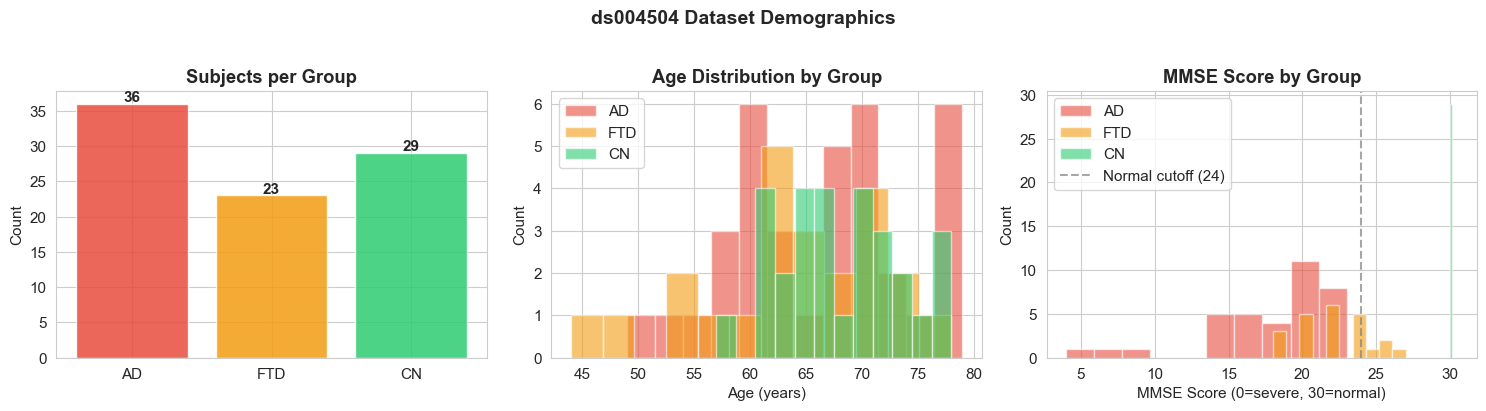

In [89]:
# Visualize group demographics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# — Group counts ——————————————————————————————————————————————————————
counts = participants['Group'].value_counts().reindex(['AD', 'FTD', 'CN'])
bars = axes[0].bar(counts.index, counts.values,
                   color=[GROUP_COLORS[g] for g in counts.index], alpha=0.85, edgecolor='white')
axes[0].set_title('Subjects per Group', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontweight='bold')

# — Age distribution ——————————————————————————————————————————————————
for group, color in GROUP_COLORS.items():
    data = participants[participants['Group'] == group]['Age'].dropna()
    axes[1].hist(data, bins=12, alpha=0.6, color=color, label=group, edgecolor='white')
axes[1].set_title('Age Distribution by Group', fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')
axes[1].legend()

# — MMSE scores ————————————————————————————————————————————————————————
for group, color in GROUP_COLORS.items():
    data = participants[participants['Group'] == group]['MMSE'].dropna()
    axes[2].hist(data, bins=10, alpha=0.6, color=color, label=group, edgecolor='white')
axes[2].set_title('MMSE Score by Group', fontweight='bold')
axes[2].set_xlabel('MMSE Score (0=severe, 30=normal)')
axes[2].set_ylabel('Count')
axes[2].axvline(x=24, color='gray', linestyle='--', alpha=0.7, label='Normal cutoff (24)')
axes[2].legend()

plt.suptitle('ds004504 Dataset Demographics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 4. Load Raw EEG with MNE <a id='4-load'></a>

The dataset is in **BIDS format** with `.set` files (EEGLAB format).  
We use `mne.io.read_raw_eeglab()` and attach the standard 10–20 montage for topographic analysis.

**Note on `pick()` vs `pick_channels()`**: MNE 1.x deprecated `pick_channels()`; always use `raw.pick(['O1','O2',...])`.


In [90]:
def load_single_subject(subject_id, dataset_root, use_derivatives=False):
    """
    Load a single subject's raw EEG from EEGLAB .set format.

    Parameters
    ----------
    subject_id : str  e.g. 'sub-001'
    dataset_root : Path
    use_derivatives : bool  if True, load from the preprocessed derivatives folder

    Returns
    -------
    mne.io.Raw
    """
    if use_derivatives:
        eeg_dir = dataset_root / 'derivatives' / subject_id / 'eeg'
    else:
        eeg_dir = dataset_root / subject_id / 'eeg'

    set_file = eeg_dir / f'{subject_id}_task-eyesclosed_eeg.set'
    if not set_file.exists():
        raise FileNotFoundError(
            f'EEG file not found: {set_file}\n'
            'The dataset repository is cloned, but the annexed EEG payload has not been '
            'downloaded yet. Run the git-annex download cell.'
        )

    raw = mne.io.read_raw_eeglab(str(set_file), preload=True, verbose=False)

    # All 19 electrodes are EEG — mark them explicitly
    raw.set_channel_types({ch: 'eeg' for ch in raw.ch_names})

    # Attach standard 10-20 montage for topology-aware analysis
    try:
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore', verbose=False)
    except Exception:
        pass  # montage optional; biomarker extraction works without it

    return raw


# Smoke-test with the first available subject
test_raw = load_single_subject(available_subjects[0], DATASET_ROOT)
print(f'Test subject:   {available_subjects[0]}')
print(f'Channels ({len(test_raw.ch_names)}): {test_raw.ch_names}')
print(f'Sampling rate:  {test_raw.info["sfreq"]} Hz')
print(f'Duration:       {test_raw.times[-1]/60:.1f} minutes')


Test subject:   sub-001
Channels (19): ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
Sampling rate:  500.0 Hz
Duration:       10.0 minutes


In [91]:
# Load ALL available subjects into memory
# This may take 2–5 minutes depending on hardware (88 × ~24 MB files)
all_raws  = {}   # subject_id -> mne.io.Raw
load_errors = []

for subj in tqdm(available_subjects, desc='Loading subjects'):
    try:
        all_raws[subj] = load_single_subject(subj, DATASET_ROOT)
    except Exception as e:
        load_errors.append((subj, str(e)))

print(f'\nSuccessfully loaded: {len(all_raws)}/{len(available_subjects)} subjects')
if load_errors:
    print('Errors:')
    for s, e in load_errors:
        print(f'  {s}: {e}')


Loading subjects:   0%|          | 0/88 [00:00<?, ?it/s]


Successfully loaded: 88/88 subjects


## 5. Dataset Overview & Visualizations <a id='5-overview'></a>

Quick sanity checks — recording duration distribution and channel layout.


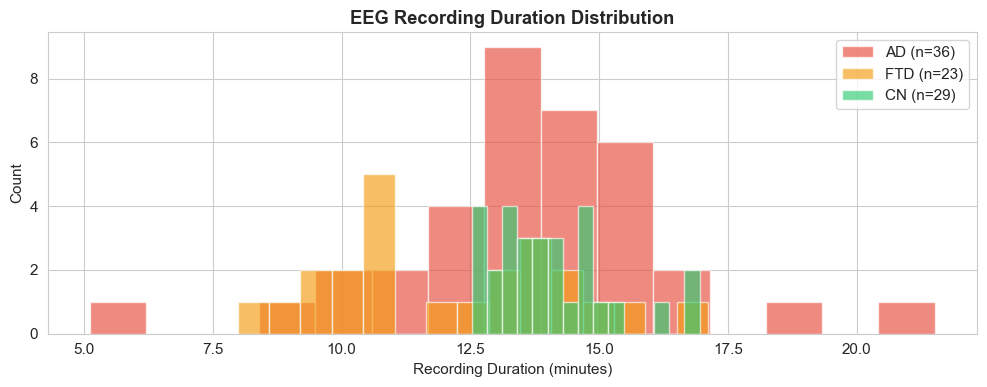

       count   mean   std    min    25%    50%    75%    max
group                                                       
AD      36.0  13.61  2.77   5.12  12.55  13.81  15.02  21.52
CN      29.0  14.04  1.19  12.52  13.16  13.78  14.73  16.95
FTD     23.0  12.14  2.35   7.98  10.51  11.74  13.78  17.11


In [92]:
# Recording duration analysis
durations = {subj: raw.times[-1] / 60 for subj, raw in all_raws.items()}
dur_df = pd.DataFrame([
    {'subject': s, 'duration_min': d, 'group': subject_to_group.get(s, '?')}
    for s, d in durations.items()
])

fig, ax = plt.subplots(figsize=(10, 4))
for group, color in GROUP_COLORS.items():
    gdata = dur_df[dur_df['group'] == group]['duration_min']
    ax.hist(gdata, bins=15, alpha=0.65, color=color, label=f'{group} (n={len(gdata)})',
            edgecolor='white')
ax.set_xlabel('Recording Duration (minutes)')
ax.set_ylabel('Count')
ax.set_title('EEG Recording Duration Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(dur_df.groupby('group')['duration_min'].describe().round(2).to_string())


## 6. Single-Subject EEG Exploration <a id='6-single'></a>

We pick one representative subject from each group for side-by-side inspection of:
- Raw time-domain traces (10-second epoch)
- Power spectral density (PSD) in the 0.5–45 Hz range
- Channel topology (10–20 electrode placement)


In [93]:
def get_first_subject(group_code):
    """Return the first subject in a given group that was successfully loaded."""
    for subj, grp in subject_to_group.items():
        if grp == group_code and subj in all_raws:
            return subj
    return None

example_subjects = {g: get_first_subject(g) for g in ['AD', 'FTD', 'CN']}
print('Example subjects selected:')
for g, s in example_subjects.items():
    print(f'  {g}: {s}')


Example subjects selected:
  AD: sub-001
  FTD: sub-066
  CN: sub-037


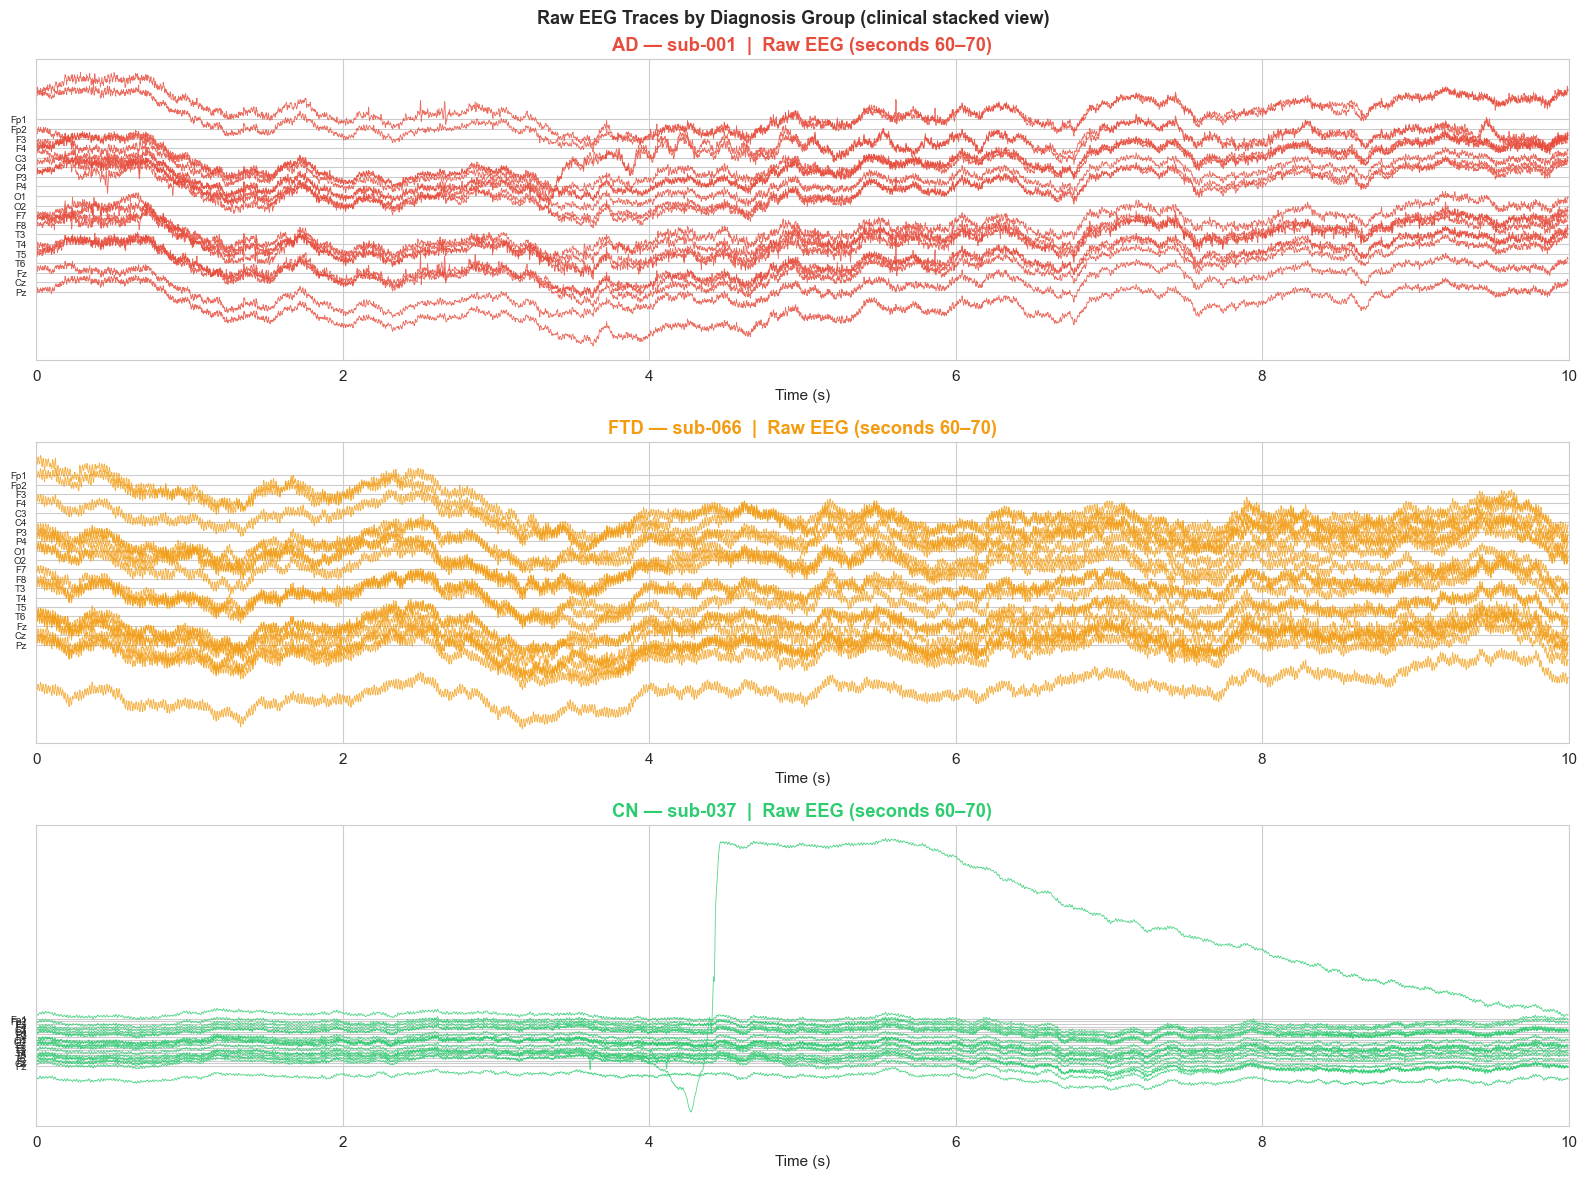

In [94]:
# ── Raw EEG traces: 10 seconds from each group ────────────────────────────────
T_START, T_END = 60, 70   # skip first minute (transition/settling artefacts)

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
for ax, (group, subj) in zip(axes, example_subjects.items()):
    if subj is None:
        ax.set_title(f'{group}: not loaded', color=GROUP_COLORS[group])
        continue
    raw = all_raws[subj]
    data, times = raw[:, int(T_START * raw.info['sfreq']):int(T_END * raw.info['sfreq'])]

    # Normalised offset stacking (clinical butterfly plot style)
    scale = 40e-6  # 40 µV per channel row
    for i, ch_data in enumerate(data):
        offset = (len(raw.ch_names) - 1 - i) * scale
        ax.plot(times - T_START, ch_data + offset, color=GROUP_COLORS[group],
                linewidth=0.6, alpha=0.8)

    ax.set_xlim(0, T_END - T_START)
    ax.set_yticks([(len(raw.ch_names) - 1 - i) * scale for i in range(len(raw.ch_names))])
    ax.set_yticklabels(raw.ch_names, fontsize=7)
    ax.set_title(f'{group} — {subj}  |  Raw EEG (seconds {T_START}–{T_END})',
                 color=GROUP_COLORS[group], fontweight='bold')
    ax.set_xlabel('Time (s)')

plt.suptitle('Raw EEG Traces by Diagnosis Group (clinical stacked view)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


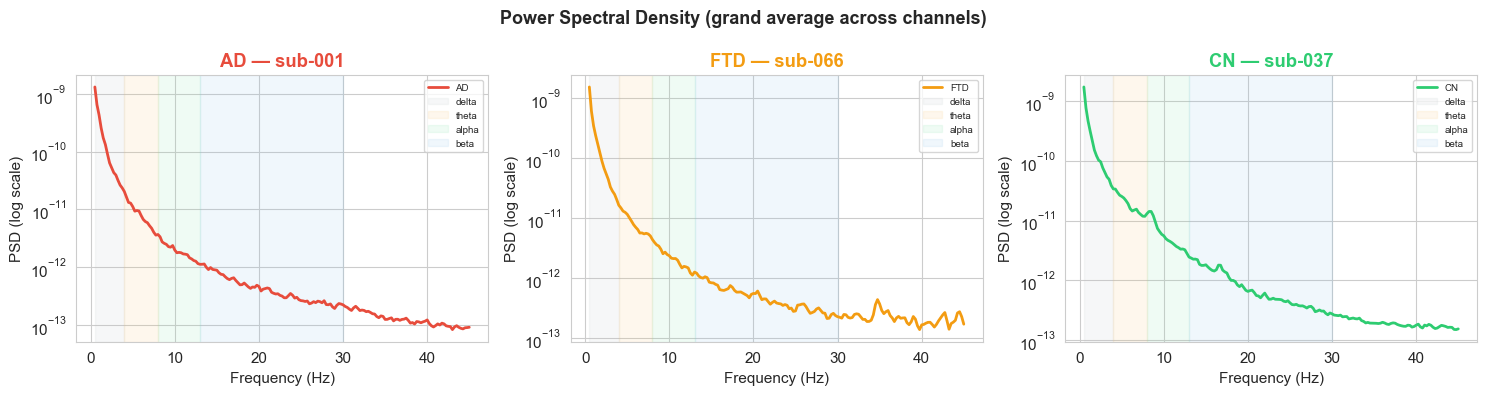

In [95]:
# ── Power Spectral Density per group ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
band_shades = {'delta':(0.5,4,'#BDC3C7'), 'theta':(4,8,'#F8C471'),
               'alpha':(8,13,'#82E0AA'), 'beta':(13,30,'#85C1E9')}

for ax, (group, subj) in zip(axes, example_subjects.items()):
    color = GROUP_COLORS[group]
    if subj is None:
        ax.set_title(f'{group}: not loaded')
        continue
    raw = all_raws[subj]
    data = raw.get_data().mean(axis=0)
    freqs_p, psd = welch(data, fs=raw.info['sfreq'], nperseg=int(raw.info['sfreq'] * 4))
    mask = (freqs_p >= 0.5) & (freqs_p <= 45)
    ax.semilogy(freqs_p[mask], psd[mask], color=color, linewidth=2, label=group)
    for bname, (flo, fhi, bc) in band_shades.items():
        ax.axvspan(flo, fhi, alpha=0.12, color=bc, label=bname)
    ax.set_title(f'{group} — {subj}', color=color, fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (log scale)')
    ax.legend(fontsize=7)

plt.suptitle('Power Spectral Density (grand average across channels)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


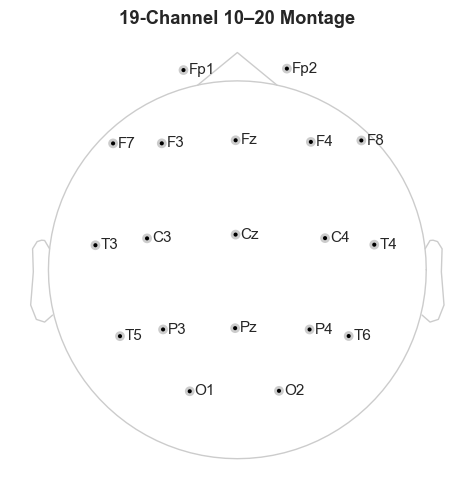

In [96]:
# ── Electrode topology ────────────────────────────────────────────────────────
sensor_subj = next((s for s in example_subjects.values() if s is not None), None)
if sensor_subj:
    fig, ax = plt.subplots(figsize=(5, 5))
    all_raws[sensor_subj].plot_sensors(show_names=True, axes=ax, show=False)
    ax.set_title('19-Channel 10–20 Montage', fontweight='bold')
    plt.tight_layout()
    plt.show()


## 7. Preprocessing Pipeline <a id='7-preprocessing'></a>

A minimal but clinically-motivated preprocessing pipeline:

| Step | Purpose |
|---|---|
| Bandpass filter 0.5–45 Hz | Remove DC drift (sub-0.5 Hz) and high-frequency noise / line interference above 45 Hz |
| Average reference | Remove common-mode noise; standard for resting-state EEG |
| Crop to 60–180 s | Skip the first minute (setup/transition artefacts); use 120 s of clean rest |

> **Why not ICA for artefact rejection?**  
> For this hackathon pipeline, we keep preprocessing minimal and deterministic to ensure reproducibility. ICA is non-deterministic and requires visual validation. In production, add ICA for ocular/cardiac artefact removal after this step.


In [97]:
def preprocess_raw(raw, l_freq=0.5, h_freq=45.0, analysis_duration=120.0):
    """
    Preprocess a raw EEG recording.

    Steps
    -----
    1. Bandpass FIR filter (0.5–45 Hz)
    2. Average reference
    3. Crop to [60 s, 60+analysis_duration s] to skip initial artefacts

    Parameters
    ----------
    raw : mne.io.Raw
    l_freq : float  Low cutoff (Hz)
    h_freq : float  High cutoff (Hz)
    analysis_duration : float  Seconds of data to retain after the initial skip

    Returns
    -------
    mne.io.Raw  (copy; original is unchanged)
    """
    raw = raw.copy()

    # 1. Bandpass filter (FIR, zero-phase)
    raw.filter(l_freq=l_freq, h_freq=h_freq, method='fir', verbose=False)

    # 2. Average reference — removes common-mode noise
    raw.set_eeg_reference('average', projection=False, verbose=False)

    # 3. Crop to the stable rest period
    t_start = 60.0
    t_end   = min(t_start + analysis_duration, raw.times[-1])
    t_start = min(t_start, raw.times[-1] - 30.0)  # guarantee ≥30 s even for short recordings
    raw.crop(tmin=t_start, tmax=t_end)

    return raw


# Quick smoke-test
raw_proc_test = preprocess_raw(all_raws[available_subjects[0]])
print(f'Preprocessed: {raw_proc_test.times[-1]:.1f} s, {len(raw_proc_test.ch_names)} channels')


Preprocessed: 120.0 s, 19 channels


In [98]:
# Preprocess all subjects (typically 1–3 minutes on CPU)
all_raws_proc = {}
for subj, raw in tqdm(all_raws.items(), desc='Preprocessing'):
    all_raws_proc[subj] = preprocess_raw(raw)

print(f'Preprocessed {len(all_raws_proc)} subjects.')


Preprocessing:   0%|          | 0/88 [00:00<?, ?it/s]

Preprocessed 88 subjects.


## 8. Biomarker Extraction <a id='8-biomarkers'></a>

We implement the biomarkers described in the hackathon slides using classical signal processing.  
These produce the **structured feature set** that feeds both §9 (per-subject summary) and §12 (statistical validation):

```
PDR_slowed              = true/false
theta_increased         = true/false
alpha_reduced           = true/false
posterior_coherence_reduced = true/false
complexity_reduced      = true/false
epileptiform_activity   = false  # requires visual EEG review
```

### Signal Processing Rationale

- **Band powers** — Welch PSD, 4-second segments, relative power (band / total broadband). Relative power removes recording gain differences across sites.
- **PDR** — Peak of the Welch PSD in the 4–14 Hz range, averaged across posterior channels (O1, O2, P3, P4, Pz). Age-corrected norm: ~9–10 Hz.
- **Posterior coherence** — Magnitude-squared coherence in the alpha band (8–13 Hz), averaged over all pairwise posterior channel combinations. Measures network synchronisation.
- **Lempel-Ziv complexity** — Binary signal complexity metric (via `antropy`). Binarise at median → proportion of unique sub-patterns. Lower = more regular / less complex.


In [99]:
# ── Constants ─────────────────────────────────────────────────────────────────
BANDS = {
    'delta': (0.5, 4),
    'theta': (4,   8),
    'alpha': (8,  13),
    'beta':  (13, 30),
    'gamma': (30, 45),
}
POSTERIOR_CHANNELS = ['O1', 'O2', 'P3', 'P4', 'Pz']


# ── Band power computation ────────────────────────────────────────────────────
def compute_band_powers(raw):
    """
    Compute relative band power per frequency band, averaged across all channels.

    Returns
    -------
    band_powers : dict  {band_name: float}  relative power in [0, 1]
    freqs       : ndarray
    psd_array   : ndarray  (n_channels, n_freqs)  raw PSD values
    """
    data  = raw.get_data()          # (n_channels, n_times)
    sfreq = raw.info['sfreq']

    # Per-channel Welch PSD
    psds  = []
    freqs = None
    for ch_data in data:
        f, p = welch(ch_data, fs=sfreq, nperseg=int(sfreq * 4))
        psds.append(p)
        freqs = f

    psd_array = np.array(psds)      # (n_channels, n_freqs)

    # Total broadband power reference
    broad_mask  = (freqs >= 0.5) & (freqs <= 45)
    total_power = psd_array[:, broad_mask].mean(axis=1)  # (n_channels,)

    band_powers = {}
    for band, (flo, fhi) in BANDS.items():
        mask = (freqs >= flo) & (freqs <= fhi)
        bp   = psd_array[:, mask].mean(axis=1)           # (n_channels,)
        band_powers[band] = float((bp / (total_power + 1e-12)).mean())

    return band_powers, freqs, psd_array


# ── Posterior Dominant Rhythm ─────────────────────────────────────────────────
def compute_pdr(raw, posterior_channels=POSTERIOR_CHANNELS):
    """
    Estimate PDR as the spectral peak in 4–14 Hz over posterior electrodes.

    Clinical norm: ~9–10 Hz for healthy adults.
    Values < 8 Hz are considered 'slowed'.
    """
    sfreq     = raw.info['sfreq']
    available = [ch for ch in posterior_channels if ch in raw.ch_names]
    if not available:
        available = raw.ch_names[-4:]   # graceful fallback

    # NOTE: use .pick() — pick_channels() is deprecated in MNE ≥ 1.0
    data = raw.copy().pick(available).get_data()
    avg  = data.mean(axis=0)
    freqs, psd = welch(avg, fs=sfreq, nperseg=int(sfreq * 4))

    pdr_mask = (freqs >= 4) & (freqs <= 14)
    pdr_hz   = freqs[pdr_mask][np.argmax(psd[pdr_mask])]
    return float(pdr_hz)


# ── Posterior alpha coherence ─────────────────────────────────────────────────
def compute_coherence_posterior(raw, posterior_channels=POSTERIOR_CHANNELS):
    """
    Mean magnitude-squared coherence in the alpha band (8–13 Hz) between
    all pairs of posterior electrodes.

    Reflects large-scale network synchrony; reduced in AD.
    """
    sfreq     = raw.info['sfreq']
    available = [ch for ch in posterior_channels if ch in raw.ch_names]
    if len(available) < 2:
        return np.nan

    # NOTE: use .pick() — pick_channels() is deprecated in MNE ≥ 1.0
    data = raw.copy().pick(available).get_data()

    coherences = []
    for i in range(len(available)):
        for j in range(i + 1, len(available)):
            f, coh = coherence(data[i], data[j], fs=sfreq, nperseg=int(sfreq * 4))
            alpha_mask = (f >= 8) & (f <= 13)
            coherences.append(coh[alpha_mask].mean())

    return float(np.mean(coherences))


# ── Lempel-Ziv complexity ─────────────────────────────────────────────────────
def compute_lempel_ziv(raw):
    """
    Lempel-Ziv complexity (normalised) — a measure of signal irregularity.

    The signal is binarised at its median before computing LZ complexity.
    Lower values = more regular, more repetitive — a hallmark of AD.
    Requires the `antropy` package; returns NaN if unavailable.
    """
    try:
        import antropy as ant
        lzc_vals = []
        for ch_data in raw.get_data():
            binary = (ch_data > np.median(ch_data)).astype(int)
            lzc_vals.append(ant.lziv_complexity(binary, normalize=True))
        return float(np.mean(lzc_vals))
    except ImportError:
        return np.nan


# ── Quick test on sub-001 ─────────────────────────────────────────────────────
if 'sub-001' in all_raws_proc:
    r = all_raws_proc['sub-001']
    bp, _, _ = compute_band_powers(r)
    pdr = compute_pdr(r)
    coh = compute_coherence_posterior(r)
    lzc = compute_lempel_ziv(r)
    print('sub-001 biomarkers:')
    print(f'  PDR:               {pdr:.2f} Hz')
    for band, power in bp.items():
        print(f'  {band:6s} rel. power: {power:.4f}')
    print(f'  Theta/Alpha ratio: {bp["theta"]/(bp["alpha"]+1e-12):.3f}')
    print(f'  Post. coherence:   {coh:.4f}')
    print(f'  LZ complexity:     {lzc:.4f}')


sub-001 biomarkers:
  PDR:               4.75 Hz
  delta  rel. power: 3.8310
  theta  rel. power: 0.9292
  alpha  rel. power: 0.2211
  beta   rel. power: 0.0794
  gamma  rel. power: 0.0683
  Theta/Alpha ratio: 4.203
  Post. coherence:   0.3865
  LZ complexity:     0.2913


In [100]:
# Compute biomarkers for ALL subjects (~2–5 minutes)
biomarker_records = []

for subj, raw in tqdm(all_raws_proc.items(), desc='Extracting biomarkers'):
    try:
        bp, _, _  = compute_band_powers(raw)
        pdr       = compute_pdr(raw)
        coh       = compute_coherence_posterior(raw)
        lzc       = compute_lempel_ziv(raw)

        rec = {
            'subject':            subj,
            'group':              subject_to_group.get(subj, 'Unknown'),
            'mmse':               subject_to_mmse.get(subj, np.nan),
            'age':                subject_to_age.get(subj, np.nan),
            'pdr_hz':             pdr,
            'posterior_coherence': coh,
            'lz_complexity':      lzc,
            **{f'{band}_power': val for band, val in bp.items()},
        }
        rec['theta_alpha_ratio'] = bp['theta'] / (bp['alpha'] + 1e-12)
        biomarker_records.append(rec)
    except Exception as e:
        print(f'  Error on {subj}: {e}')

biomarkers_df = pd.DataFrame(biomarker_records)
print(f'Extracted biomarkers for {len(biomarkers_df)} subjects.')
biomarkers_df.head(3)


Extracting biomarkers:   0%|          | 0/88 [00:00<?, ?it/s]

Extracted biomarkers for 88 subjects.


,subject,group,mmse,age,pdr_hz,posterior_coherence,lz_complexity,delta_power,theta_power,alpha_power,beta_power,gamma_power,theta_alpha_ratio
0,sub-001,AD,16,57,4.75,0.386454,0.291343,3.830960,0.929189,0.221099,0.079387,0.068298,4.202591
1,sub-002,AD,22,78,8.50,0.430011,0.271140,2.608541,1.013421,1.588236,0.135510,0.043198,0.638080
2,sub-003,AD,14,70,9.00,0.305838,0.234801,2.238747,1.984096,1.746505,0.049962,0.014543,1.136038


In [101]:
# Save biomarkers CSV for downstream LLM pipeline
output_dir = (DATASET_ROOT / '..').resolve()   # one level up from ds004504/
output_dir.mkdir(exist_ok=True)
csv_path = output_dir / 'biomarkers_all_subjects.csv'
biomarkers_df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')


Saved: /Users/michaelburiek/Documents/GitHub/eeg_hackathon/data/biomarkers_all_subjects.csv


## 9. Per-Subject Biomarker Summary <a id='9-summary'></a>

This is the **classical pipeline output** — the interface between signal processing and LLM reasoning.

For each subject we produce a structured text summary of their biomarker profile relative to
healthy controls (CN), which becomes one of two evidence streams fed to the LLM in §14.

The z-score threshold (default 1.5 SD from CN mean) determines when a biomarker is flagged
as abnormal. This threshold is conservative by design — we prefer fewer false alarms over
missing a real signal.


In [102]:
# Compute group-level norms using CN (healthy controls) as the reference population
cn_data = biomarkers_df[biomarkers_df['group'] == 'CN']

norms = {
    'pdr_hz_mean':               cn_data['pdr_hz'].mean(),
    'pdr_hz_std':                cn_data['pdr_hz'].std(),
    'alpha_power_mean':          cn_data['alpha_power'].mean(),
    'theta_alpha_ratio_mean':    cn_data['theta_alpha_ratio'].mean(),
    'theta_alpha_ratio_std':     cn_data['theta_alpha_ratio'].std(),
    'posterior_coherence_mean':  cn_data['posterior_coherence'].mean(),
    'posterior_coherence_std':   cn_data['posterior_coherence'].std(),
    'lz_complexity_mean':        cn_data['lz_complexity'].mean(),
    'lz_complexity_std':         cn_data['lz_complexity'].std(),
}

print('CN (healthy control) reference norms:')
for k, v in norms.items():
    print(f'  {k:38s} = {v:.4f}')


CN (healthy control) reference norms:
  pdr_hz_mean                            = 9.2586
  pdr_hz_std                             = 1.6883
  alpha_power_mean                       = 1.1954
  theta_alpha_ratio_mean                 = 0.6572
  theta_alpha_ratio_std                  = 0.7874
  posterior_coherence_mean               = 0.3799
  posterior_coherence_std                = 0.0901
  lz_complexity_mean                     = 0.2643
  lz_complexity_std                      = 0.0468


In [103]:
def generate_biomarker_summary(row, norms, z_thresh=1.5):
    """
    Generate a structured biomarker summary for one subject.

    A flag is raised when a biomarker deviates from the CN norm by ≥ z_thresh
    standard deviations in the expected direction.

    Parameters
    ----------
    row      : pd.Series  one row from biomarkers_df
    norms    : dict       CN reference statistics
    z_thresh : float      z-score threshold for binary flagging (default 1.5)

    Returns
    -------
    flags : dict of bool
    quant : dict of float
    text  : str  formatted report
    """
    # Z-scores relative to CN
    pdr_z = (row['pdr_hz']           - norms['pdr_hz_mean'])              / (norms['pdr_hz_std']              + 1e-9)
    ta_z  = (row['theta_alpha_ratio'] - norms['theta_alpha_ratio_mean'])   / (norms['theta_alpha_ratio_std']   + 1e-9)
    coh_z = (row['posterior_coherence']- norms['posterior_coherence_mean'])/ (norms['posterior_coherence_std'] + 1e-9)
    lzc_z = (row['lz_complexity']     - norms['lz_complexity_mean'])       / (norms['lz_complexity_std']       + 1e-9)

    flags = {
        'PDR_slowed':                  bool(row['pdr_hz'] < 8.0 or pdr_z < -z_thresh),
        'theta_increased':             bool(ta_z > z_thresh),
        'alpha_reduced':               bool(row['alpha_power'] < norms['alpha_power_mean'] * 0.85),
        'posterior_coherence_reduced': bool(coh_z < -z_thresh),
        'complexity_reduced':          bool(lzc_z < -z_thresh),
        'epileptiform_activity':       False,  # requires visual EEG review
    }

    quant = {
        'pdr_hz':              round(float(row['pdr_hz']),             2),
        'theta_power_pct':     round(float(row['theta_power']) * 100,  1),
        'alpha_power_pct':     round(float(row['alpha_power']) * 100,  1),
        'theta_alpha_ratio':   round(float(row['theta_alpha_ratio']),  3),
        'posterior_coherence': round(float(row['posterior_coherence']),3),
        'lz_complexity':       round(float(row['lz_complexity']),      4),
    }

    text = (
        f"Subject: {row['subject']}  |  Age: {row['age']}  |  MMSE: {row['mmse']}\n"
        f"True Group: {row['group']}  (blinded in real use — for validation only)\n"
        f"\n--- QUANTITATIVE BIOMARKERS ---\n"
        f"Posterior Dominant Rhythm:   {quant['pdr_hz']:.2f} Hz"
        f"  (CN norm: {norms['pdr_hz_mean']:.1f} ± {norms['pdr_hz_std']:.1f} Hz)\n"
        f"Theta power:                 {quant['theta_power_pct']:.1f}%  (relative)\n"
        f"Alpha power:                 {quant['alpha_power_pct']:.1f}%  (relative)\n"
        f"Theta/Alpha ratio:           {quant['theta_alpha_ratio']:.3f}"
        f"  (CN norm: {norms['theta_alpha_ratio_mean']:.3f})\n"
        f"Posterior alpha coherence:   {quant['posterior_coherence']:.3f}"
        f"  (CN norm: {norms['posterior_coherence_mean']:.3f})\n"
        f"Lempel-Ziv complexity:       {quant['lz_complexity']:.4f}"
        f"  (CN norm: {norms['lz_complexity_mean']:.4f})\n"
        f"\n--- BINARY FLAGS (for LLM reasoning) ---\n"
    )
    for flag, val in flags.items():
        text += f"{flag:38s} = {str(val).lower()}\n"

    return flags, quant, text


# Demonstrate for one subject per group
for group in ['AD', 'FTD', 'CN']:
    subj = example_subjects.get(group)
    if subj is None or subj not in all_raws_proc:
        continue
    rows = biomarkers_df[biomarkers_df['subject'] == subj]
    if rows.empty:
        continue
    _, _, text = generate_biomarker_summary(rows.iloc[0], norms)
    print('=' * 68)
    print(text)


Subject: sub-001  |  Age: 57  |  MMSE: 16
True Group: AD  (blinded in real use — for validation only)

--- QUANTITATIVE BIOMARKERS ---
Posterior Dominant Rhythm:   4.75 Hz  (CN norm: 9.3 ± 1.7 Hz)
Theta power:                 92.9%  (relative)
Alpha power:                 22.1%  (relative)
Theta/Alpha ratio:           4.203  (CN norm: 0.657)
Posterior alpha coherence:   0.386  (CN norm: 0.380)
Lempel-Ziv complexity:       0.2913  (CN norm: 0.2643)

--- BINARY FLAGS (for LLM reasoning) ---
PDR_slowed                             = true
theta_increased                        = true
alpha_reduced                          = true
posterior_coherence_reduced            = false
complexity_reduced                     = false
epileptiform_activity                  = false

Subject: sub-066  |  Age: 73  |  MMSE: 20
True Group: FTD  (blinded in real use — for validation only)

--- QUANTITATIVE BIOMARKERS ---
Posterior Dominant Rhythm:   7.75 Hz  (CN norm: 9.3 ± 1.7 Hz)
Theta power:                

In [104]:
# Generate summaries for ALL subjects and save to disk
summaries = []
for _, row in biomarkers_df.iterrows():
    try:
        flags, quant, text = generate_biomarker_summary(row, norms)
        summaries.append({
            'subject':      row['subject'],
            'group':        row['group'],
            'mmse':         row['mmse'],
            'age':          row['age'],
            'summary_text': text,
            **flags,
            **quant,
        })
    except Exception as e:
        print(f'Error on {row["subject"]}: {e}')

summaries_df = pd.DataFrame(summaries)
summaries_df.to_csv(output_dir / 'eeg_biomarker_summaries.csv', index=False)

# Individual text files — one per subject — for direct LLM ingestion
summaries_dir = output_dir / 'subject_summaries'
summaries_dir.mkdir(exist_ok=True)
for _, row in summaries_df.iterrows():
    (summaries_dir / f"{row['subject']}_biomarkers.txt").write_text(row['summary_text'])

print(f'Saved {len(summaries_df)} summaries.')
print(f'  CSV:              {output_dir / "eeg_biomarker_summaries.csv"}')
print(f'  Individual texts: {summaries_dir}/')


Saved 88 summaries.
  CSV:              /Users/michaelburiek/Documents/GitHub/eeg_hackathon/data/eeg_biomarker_summaries.csv
  Individual texts: /Users/michaelburiek/Documents/GitHub/eeg_hackathon/data/subject_summaries/


Biomarker Flag Rate (% subjects per group):
group                          AD   FTD    CN
PDR_slowed                   63.9  47.8   6.9
theta_increased              58.3  34.8   3.4
alpha_reduced                80.6  82.6  44.8
posterior_coherence_reduced   8.3  13.0   0.0
complexity_reduced            8.3  17.4   3.4


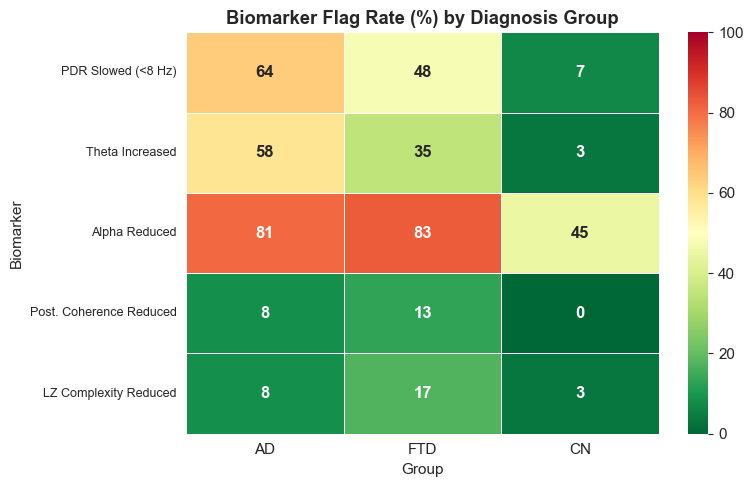

In [105]:
# ── Flag Rate Analysis: what % of each group triggers each biomarker flag? ───
flag_cols = ['PDR_slowed', 'theta_increased', 'alpha_reduced',
             'posterior_coherence_reduced', 'complexity_reduced']

flag_rates = summaries_df.groupby('group')[flag_cols].mean().T * 100
flag_rates = flag_rates.reindex(columns=['AD', 'FTD', 'CN'], fill_value=0)

print('Biomarker Flag Rate (% subjects per group):')
print(flag_rates.round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(flag_rates, annot=True, fmt='.0f', cmap='RdYlGn_r',
            vmin=0, vmax=100, ax=ax, linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Biomarker Flag Rate (%) by Diagnosis Group', fontweight='bold')
ax.set_xlabel('Group')
ax.set_ylabel('Biomarker')
ax.set_yticklabels([
    'PDR Slowed (<8 Hz)',
    'Theta Increased',
    'Alpha Reduced',
    'Post. Coherence Reduced',
    'LZ Complexity Reduced',
], rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


## 10. Deep EEG Model: EEGConformer <a id='10-deep-model'></a>

### Why a deep model alongside classical biomarkers?

Classical biomarkers (§8) encode *known* clinical knowledge — they can only find
what we told them to look for. A deep model trained on raw EEG windows learns representations
directly from data and can discover discriminative patterns that clinicians haven't explicitly named.

The model doesn't replace clinical knowledge — it **augments** it. In §12 we statistically
validate what the model finds, and in §14 the LLM reasons over both streams together.

### Architecture: EEGConformer

[EEGConformer](https://arxiv.org/abs/2201.02184) is a hybrid CNN + Transformer designed for EEG:

```
Input: (batch, 19 channels, 2000 time points)
    ↓
Temporal Conv Block     — learns local time-frequency features (like a learned bandpass filter)
    ↓
Spatial Conv Block      — learns cross-channel mixtures (like a learned spatial filter)
    ↓
Multi-Head Self-Attention  — models which time segments are related to each other
    ↓
FC + Softmax            — P(AD), P(FTD), P(CN)
```

### Handling the small dataset (n=88)

With only 88 subjects, naive training would overfit immediately. We mitigate this with:

| Technique | Why |
|---|---|
| **Subject-stratified 5-fold CV** | Split by subject not by window — prevents data leakage |
| **Heavy dropout** (0.5) | Prevents the model memorizing individual recordings |
| **Class-weighted loss** | Corrects for imbalance: 36 AD, 29 CN, 23 FTD |
| **Cosine LR schedule** | Smooth convergence without manual tuning |

> **Data leakage warning**: A 10-minute recording produces ~150 overlapping 4-second windows.
> If you split by window, train and test sets share windows from the same recording — the model
> essentially memorizes subjects. Always split by subject.

> **Further reading**: [EEGConformer paper](https://arxiv.org/abs/2201.02184) |
> [braindecode model zoo](https://braindecode.org/stable/api.html#models)


In [106]:
# ── Deep model imports ──────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from braindecode.models import EEGConformer
from braindecode.datasets import RawDataset, BaseConcatDataset
from braindecode.preprocessing import create_fixed_length_windows

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


PyTorch version: 2.11.0
Device: cpu


In [107]:
# ── Build full windowed dataset for all subjects ────────────────────────────
#
# We use the preprocessed raws from Section 7.
# Each 4-second window (2000 samples) becomes one training example.
#
# Label mapping:
#   AD  → 0  (Alzheimer's Disease)
#   FTD → 1  (Frontotemporal Dementia)
#   CN  → 2  (Healthy Control)

group_to_label = {'AD': 0, 'FTD': 1, 'CN': 2}
label_to_group = {v: k for k, v in group_to_label.items()}

all_datasets = []
subject_labels = []   # parallel list: one entry per subject

for subj, raw in all_raws_proc.items():
    group = subject_to_group.get(subj)
    if group not in group_to_label:
        continue
    label = group_to_label[group]
    description = pd.Series({
        'subject': subj,
        'group':   group,
        'target':  label,
    })
    ds = RawDataset(raw.copy(), description=description, target_name='target')
    all_datasets.append(ds)
    subject_labels.append(label)

full_concat = BaseConcatDataset(all_datasets)
print(f'Total subjects in dataset: {len(all_datasets)}')
print(f'Label distribution: { {label_to_group[l]: subject_labels.count(l) for l in set(subject_labels)} }')

# Determine window parameters from first subject's sampling rate
sfreq            = all_raws_proc[next(iter(all_raws_proc))].info['sfreq']
WINDOW_SIZE_S    = 4.0                        # seconds per window
WINDOW_STRIDE_S  = 2.0                        # 50% overlap
WINDOW_SIZE_SAMP = int(WINDOW_SIZE_S * sfreq)
STRIDE_SAMP      = int(WINDOW_STRIDE_S * sfreq)
N_CHANNELS       = 19

print(f'\nWindow size: {WINDOW_SIZE_SAMP} samples ({WINDOW_SIZE_S}s @ {sfreq:.0f} Hz)')
print(f'Stride:      {STRIDE_SAMP} samples ({WINDOW_STRIDE_S}s)')


Total subjects in dataset: 88
Label distribution: {'AD': 36, 'FTD': 23, 'CN': 29}

Window size: 2000 samples (4.0s @ 500 Hz)
Stride:      1000 samples (2.0s)


In [108]:
# ── Create windowed dataset ──────────────────────────────────────────────────
#
# create_fixed_length_windows slices each Raw recording into overlapping epochs.
# The result is a BaseConcatDataset of EEGWindowsDatasets.

full_windows = create_fixed_length_windows(
    full_concat,
    window_size_samples   = WINDOW_SIZE_SAMP,
    window_stride_samples = STRIDE_SAMP,
    drop_last_window      = True,
    preload               = True,
    verbose               = False,
)

# Build a parallel array: window index → subject index (for stratified splitting)
# Each EEGWindowsDataset in full_windows.datasets corresponds to one subject
window_subject_ids = []   # for each window: which subject it came from
window_labels      = []   # for each window: its class label

for subj_idx, subj_ds in enumerate(full_windows.datasets):
    n_windows = len(subj_ds)
    window_subject_ids.extend([subj_idx] * n_windows)
    window_labels.extend([subject_labels[subj_idx]] * n_windows)

window_subject_ids = np.array(window_subject_ids)
window_labels      = np.array(window_labels)

total_windows = len(window_labels)
print(f'Total windows: {total_windows}')
print(f'Per-class windows:')
for lbl, name in label_to_group.items():
    print(f'  {name}: {(window_labels == lbl).sum()}')


Total windows: 5192
Per-class windows:
  AD: 2124
  FTD: 1357
  CN: 1711


In [109]:
# ── Model definition and training utilities ──────────────────────────────────

def build_model(n_channels=19, n_times=2000, n_outputs=3, sfreq=500.0):
    """
    Instantiate EEGConformer for our EEG classification task.

    EEGConformer architecture:
    - Temporal convolution: learns time-frequency features
    - Spatial convolution: learns cross-channel mixtures
    - Multi-head self-attention: models long-range temporal dependencies
    - FC head: maps to class probabilities
    """
    model = EEGConformer(
        n_outputs        = n_outputs,
        n_chans          = n_channels,
        n_times          = n_times,
        sfreq            = sfreq,
        num_layers       = 4,       # fewer layers for small dataset
        num_heads        = 4,       # attention heads
        drop_prob        = 0.5,     # heavy dropout — critical for 88 subjects
        att_drop_prob    = 0.3,
        final_fc_length  = 'auto',
    )
    return model


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for X, y, _ in loader:
        X, y = X.to(DEVICE, dtype=torch.float32), y.to(DEVICE, dtype=torch.long)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (out.argmax(1) == y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for X, y, _ in loader:
        X = X.to(DEVICE, dtype=torch.float32)
        preds = model(X).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())
    return np.array(all_preds), np.array(all_labels)


# Compute class weights to handle imbalance (36 AD, 29 CN, 23 FTD)
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',
    classes=np.array([0, 1, 2]),
    y=window_labels
)
class_weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f'Class weights: AD={class_weights[0]:.2f}, FTD={class_weights[1]:.2f}, CN={class_weights[2]:.2f}')
print('(Higher weight = model penalised more for mistakes on that class)')


Class weights: AD=0.81, FTD=1.28, CN=1.01
(Higher weight = model penalised more for mistakes on that class)


In [110]:
# ── 5-Fold Cross-Validation Training ─────────────────────────────────────────
#
# IMPORTANT: We split by SUBJECT, not by window.
# Splitting by window would cause data leakage — windows from the same
# 10-minute recording are highly correlated and an 80/20 window split
# would give falsely optimistic accuracy.
#
# Strategy:
#   1. Split 88 subjects into 5 folds (stratified by group)
#   2. For each fold: train on windows from 70 subjects, test on ~18 subjects
#   3. Aggregate predictions across all folds

N_EPOCHS    = 20    # intentionally short — demonstration purposes
BATCH_SIZE  = 64
LR          = 1e-4

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
subject_indices  = np.arange(len(all_datasets))
subject_labels_a = np.array(subject_labels)

fold_results   = []    # per-fold accuracy
all_test_preds = np.full(len(window_labels), -1, dtype=int)  # aggregated predictions

print(f'Training EEGConformer with 5-fold cross-validation')
print(f'Epochs: {N_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}')
print(f'Device: {DEVICE}')
print('─' * 60)

for fold, (train_subj_idx, test_subj_idx) in enumerate(
        skf.split(subject_indices, subject_labels_a)):

    # Identify which WINDOWS belong to train/test subjects
    train_win_mask = np.isin(window_subject_ids, train_subj_idx)
    test_win_mask  = np.isin(window_subject_ids, test_subj_idx)

    train_indices = np.where(train_win_mask)[0]
    test_indices  = np.where(test_win_mask)[0]

    train_loader = DataLoader(
        Subset(full_windows, train_indices),
        batch_size=BATCH_SIZE, shuffle=True,  drop_last=True
    )
    test_loader = DataLoader(
        Subset(full_windows, test_indices),
        batch_size=BATCH_SIZE, shuffle=False
    )

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

    best_val_acc = 0.
    best_state   = None

    for epoch in range(N_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        scheduler.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            preds, labels = evaluate(model, test_loader)
            val_acc = (preds == labels).mean()
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'  Fold {fold+1} | Epoch {epoch+1:2d}/{N_EPOCHS} | '
                  f'loss={train_loss:.3f} train_acc={train_acc:.3f} val_acc={val_acc:.3f}')

    # Restore best weights and collect test predictions for this fold
    model.load_state_dict(best_state)
    fold_preds, fold_labels = evaluate(model, test_loader)
    all_test_preds[test_indices] = fold_preds

    fold_acc = (fold_preds == fold_labels).mean()
    fold_results.append(fold_acc)
    print(f'  ✓ Fold {fold+1} best val_acc: {best_val_acc:.3f}')
    print()

print(f'Cross-validation accuracy: {np.mean(fold_results):.3f} ± {np.std(fold_results):.3f}')


Training EEGConformer with 5-fold cross-validation
Epochs: 20 | Batch: 64 | LR: 0.0001
Device: cpu
────────────────────────────────────────────────────────────
  Fold 1 | Epoch  1/20 | loss=1.120 train_acc=0.325 val_acc=0.278
  Fold 1 | Epoch  5/20 | loss=1.110 train_acc=0.335 val_acc=0.278
  Fold 1 | Epoch 10/20 | loss=1.108 train_acc=0.334 val_acc=0.278
  Fold 1 | Epoch 15/20 | loss=1.105 train_acc=0.331 val_acc=0.278
  Fold 1 | Epoch 20/20 | loss=1.106 train_acc=0.326 val_acc=0.278
  ✓ Fold 1 best val_acc: 0.278

  Fold 2 | Epoch  1/20 | loss=1.128 train_acc=0.344 val_acc=0.333
  Fold 2 | Epoch  5/20 | loss=1.110 train_acc=0.336 val_acc=0.333
  Fold 2 | Epoch 10/20 | loss=1.105 train_acc=0.336 val_acc=0.278
  Fold 2 | Epoch 15/20 | loss=1.105 train_acc=0.342 val_acc=0.278
  Fold 2 | Epoch 20/20 | loss=1.104 train_acc=0.344 val_acc=0.389
  ✓ Fold 2 best val_acc: 0.389

  Fold 3 | Epoch  1/20 | loss=1.121 train_acc=0.347 val_acc=0.333
  Fold 3 | Epoch  5/20 | loss=1.111 train_acc=0.33

Classification Report (window-level):
              precision    recall  f1-score   support

          AD      0.396     0.583     0.472      2124
         FTD      0.235     0.174     0.200      1357
          CN      0.278     0.172     0.213      1711

    accuracy                          0.341      5192
   macro avg      0.303     0.310     0.295      5192
weighted avg      0.315     0.341     0.315      5192



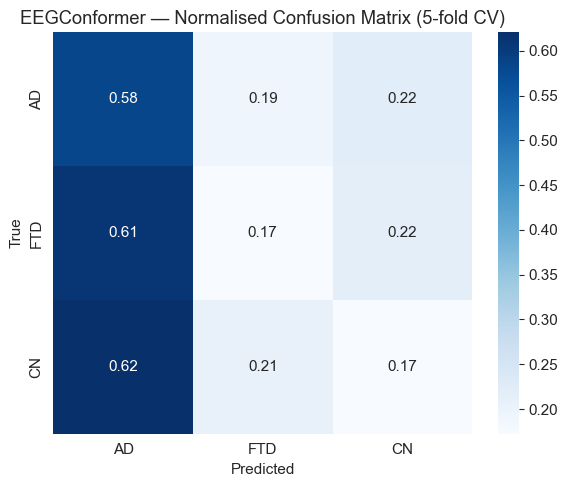


Note: Window-level accuracy will be higher than subject-level accuracy.
Windows from the same recording are correlated — this is expected.
For clinical deployment, always aggregate window predictions per subject.


In [111]:
# ── Evaluation: Confusion Matrix & Classification Report ────────────────────
#
# We only evaluate on windows that were part of a test fold (all of them in CV).

valid_mask = all_test_preds >= 0
y_pred = all_test_preds[valid_mask]
y_true = window_labels[valid_mask]

print('Classification Report (window-level):')
print(classification_report(y_true, y_pred,
      target_names=['AD', 'FTD', 'CN'], digits=3))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['AD', 'FTD', 'CN'],
            yticklabels=['AD', 'FTD', 'CN'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('EEGConformer — Normalised Confusion Matrix (5-fold CV)')
plt.tight_layout()
plt.show()

print()
print('Note: Window-level accuracy will be higher than subject-level accuracy.')
print('Windows from the same recording are correlated — this is expected.')
print('For clinical deployment, always aggregate window predictions per subject.')


## 11. Attribution Maps: What Did the Model Actually Use? <a id='11-attribution'></a>

### Attention ≠ Explanation

A common mistake is equating a model's **attention weights** with its **explanation**.
Attention tells us which parts of the input the model *focused on* — but not whether
those parts *caused* the prediction.

> *"Attention is not explanation"* — [Jain & Wallace, 2019](https://arxiv.org/abs/1902.10186)

We use **Integrated Gradients (IG)**, a gradient-based attribution method that is provably
faithful: it satisfies *completeness* (attributions sum to the model's output) and
*sensitivity* (a feature that changes the output must receive non-zero attribution).

### How Integrated Gradients works

```
Attribution(xᵢ) = (xᵢ - x̄ᵢ) × ∫₀¹ ∂F(x̄ + α(x-x̄))/∂xᵢ dα
```

In plain terms:
1. Start from a **baseline** (all-zeros EEG — no signal)
2. Interpolate from baseline to the actual input in N steps
3. Compute gradients at each step
4. Average the gradients, weighted by the input values

The result is a score for every **(channel, time_sample)** pair indicating how much
it contributed to the model's prediction.

> **Further reading**: [Integrated Gradients paper](https://arxiv.org/abs/1703.01365) |
> [captum library](https://captum.ai/) | [Attention is not explanation](https://arxiv.org/abs/1902.10186)


In [112]:
# ── Set up Integrated Gradients with captum ──────────────────────────────────
from captum.attr import IntegratedGradients

# We use the final cross-validation model (last fold) for attribution.
# In production you'd average attributions across all fold models.
model.eval()
model.to(DEVICE)

ig = IntegratedGradients(model)

print('IntegratedGradients ready.')
print('Baseline: all-zeros tensor (silence — no EEG signal)')
print(f'Input shape per window: (1, {N_CHANNELS}, {WINDOW_SIZE_SAMP})')


IntegratedGradients ready.
Baseline: all-zeros tensor (silence — no EEG signal)
Input shape per window: (1, 19, 2000)


In [113]:
# ── Compute per-group attribution maps ───────────────────────────────────────
#
# For each group (AD, FTD, CN), we:
#   1. Collect all test windows from the last CV fold
#   2. Compute Integrated Gradients for each window
#   3. Average attributions → group-level attribution map
#
# Shape of attribution map: (19 channels, 2000 time samples)
# We take the absolute value — we care about magnitude, not direction.

N_IG_STEPS  = 50     # number of interpolation steps (50 is standard; 300 for publication)
MAX_WINDOWS = 30     # cap per group for speed (remove for full run)

group_attributions = {name: [] for name in ['AD', 'FTD', 'CN']}
group_inputs       = {name: [] for name in ['AD', 'FTD', 'CN']}

# Use last fold test set (test_indices from final fold above)
test_subset = Subset(full_windows, test_indices)
test_loader_attr = DataLoader(test_subset, batch_size=1, shuffle=False)

model.eval()
print(f'Computing Integrated Gradients on {len(test_indices)} test windows...')
print(f'(capped at {MAX_WINDOWS} per group for speed)')

with torch.no_grad():
    pass  # just to verify model is in eval mode

for X, y, _ in tqdm(test_loader_attr, desc='Attribution'):
    label = y.item()
    group = label_to_group[label]

    if len(group_attributions[group]) >= MAX_WINDOWS:
        continue

    X_input   = X.to(DEVICE, dtype=torch.float32)
    baseline  = torch.zeros_like(X_input)  # all-zero baseline = silence

    # target: compute attribution w.r.t. the TRUE class
    # This answers: "what contributed to the model predicting this class?"
    attrs = ig.attribute(
        X_input,
        baselines    = baseline,
        target       = label,
        n_steps      = N_IG_STEPS,
        return_convergence_delta = False,
    )

    # attrs shape: (1, 19, 2000) — take absolute value (importance, not direction)
    group_attributions[group].append(attrs.squeeze().abs().cpu().numpy())
    group_inputs[group].append(X.squeeze().cpu().numpy())

# Average across windows → one attribution map per group
group_attr_mean = {}
for grp, attrs_list in group_attributions.items():
    if attrs_list:
        group_attr_mean[grp] = np.stack(attrs_list).mean(axis=0)  # (19, 2000)
        print(f'{grp}: averaged {len(attrs_list)} windows')

print('\nAttribution maps computed.')


Computing Integrated Gradients on 1003 test windows...
(capped at 30 per group for speed)


Attribution:   0%|          | 0/1003 [00:00<?, ?it/s]

AD: averaged 30 windows
FTD: averaged 30 windows
CN: averaged 30 windows

Attribution maps computed.


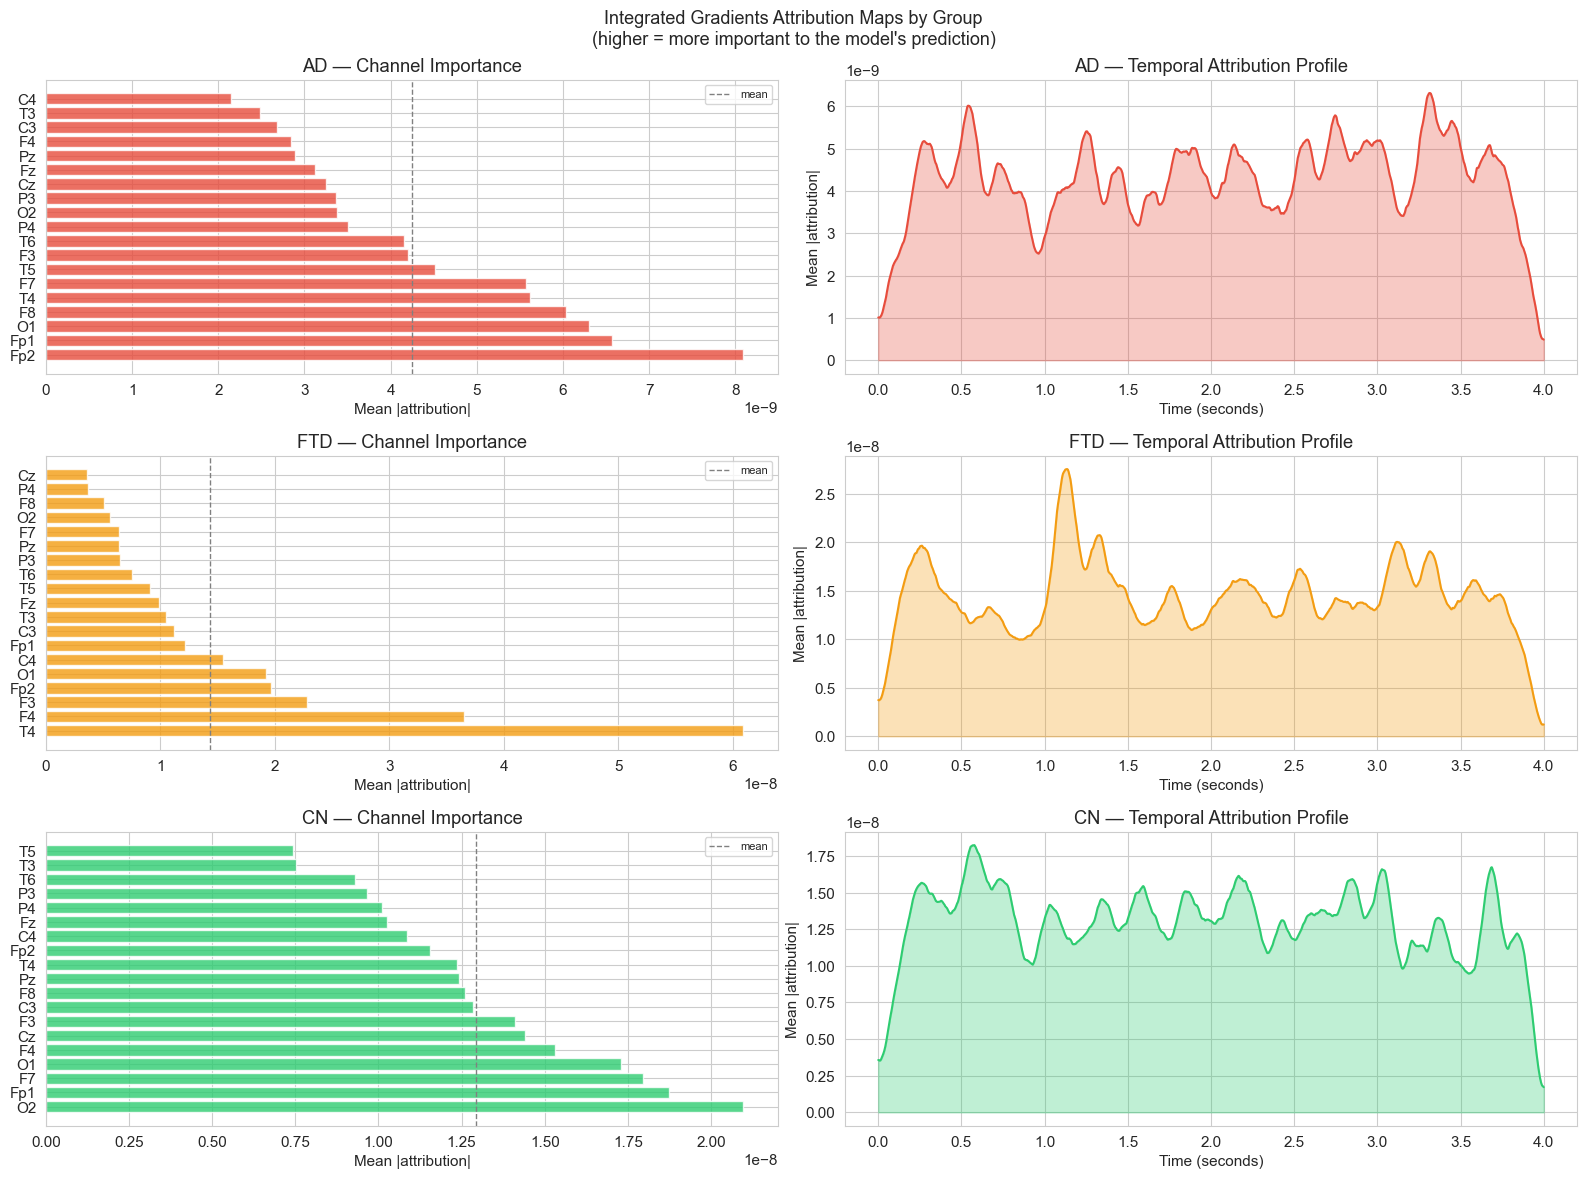

In [114]:
# ── Visualise attribution maps ────────────────────────────────────────────────
#
# We show two views:
#   1. Time-averaged attribution per channel → which channels matter most?
#   2. Channel-averaged attribution over time → which time periods matter most?

ch_names = all_raws_proc[next(iter(all_raws_proc))].ch_names
time_axis = np.linspace(0, WINDOW_SIZE_S, WINDOW_SIZE_SAMP)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Integrated Gradients Attribution Maps by Group\n'
             '(higher = more important to the model\'s prediction)', fontsize=13)

for row, group in enumerate(['AD', 'FTD', 'CN']):
    if group not in group_attr_mean:
        continue
    attr = group_attr_mean[group]   # (19, 2000)
    color = GROUP_COLORS[group]

    # ── Left: per-channel importance (time-averaged) ────────────────────────
    ax_ch = axes[row, 0]
    ch_importance = attr.mean(axis=1)   # (19,)
    sorted_idx    = np.argsort(ch_importance)[::-1]
    ax_ch.barh([ch_names[i] for i in sorted_idx],
               ch_importance[sorted_idx],
               color=color, alpha=0.8)
    ax_ch.set_xlabel('Mean |attribution|')
    ax_ch.set_title(f'{group} — Channel Importance')
    ax_ch.axvline(ch_importance.mean(), color='gray', ls='--', lw=1, label='mean')
    ax_ch.legend(fontsize=8)

    # ── Right: time-course of importance (channel-averaged) ─────────────────
    ax_t = axes[row, 1]
    time_importance = attr.mean(axis=0)   # (2000,)
    # Smooth for readability
    from scipy.ndimage import uniform_filter1d
    time_smooth = uniform_filter1d(time_importance, size=50)
    ax_t.plot(time_axis, time_smooth, color=color, lw=1.5)
    ax_t.fill_between(time_axis, 0, time_smooth, alpha=0.3, color=color)
    ax_t.set_xlabel('Time (seconds)')
    ax_t.set_ylabel('Mean |attribution|')
    ax_t.set_title(f'{group} — Temporal Attribution Profile')

plt.tight_layout()
plt.show()


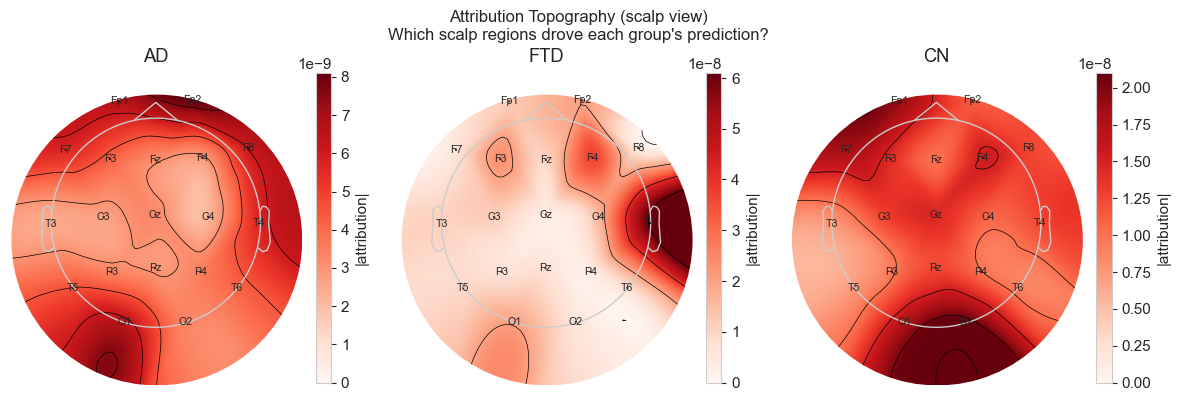

In [115]:
# ── Topographic attribution map ──────────────────────────────────────────────
#
# Plot attribution as a scalp topography using MNE's built-in topomap.
# This shows SPATIALLY where the model is looking on the scalp.

from mne.viz import plot_topomap

ref_raw    = all_raws_proc[next(iter(all_raws_proc))]
info       = ref_raw.info

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Attribution Topography (scalp view)\n'
             'Which scalp regions drove each group\'s prediction?', fontsize=12)

for ax, group in zip(axes, ['AD', 'FTD', 'CN']):
    if group not in group_attr_mean:
        ax.set_visible(False)
        continue

    ch_importance = group_attr_mean[group].mean(axis=1)   # (19,)

    im, _ = plot_topomap(
        ch_importance,
        info,
        axes      = ax,
        show      = False,
        cmap      = 'Reds',
        contours  = 4,
        sphere    = 'auto',
        names     = ref_raw.ch_names,
    )
    ax.set_title(f'{group}')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='|attribution|')

plt.tight_layout()
plt.show()


## 12. Statistical Validation: Is the Attribution Real? <a id='12-stats'></a>

### The problem with trusting attribution blindly

A model trained on 88 subjects in 5-fold CV may be partially overfitting.
Even a well-regularised model's attributions could reflect **spurious correlations**
rather than genuine neurological signal.

We validate attributed regions with **three independent statistical tests**:

| Test | What it checks | Threshold |
|---|---|---|
| **Kruskal-Wallis H** | Do the 3 groups differ in this feature? (non-parametric ANOVA) | p < 0.05 |
| **Eta-squared (η²)** | How large is the group difference? | η² > 0.06 (medium effect) |
| **Permutation test** | Could this attribution arise by chance? | p_perm < 0.05 |

Only (channel, frequency band) pairs that pass **all three** tests are passed to the LLM.
This ensures the LLM reasons from statistically grounded evidence, not model artifacts.

> **Why non-parametric?** With group sizes of 23–36, we cannot assume normality.
> Kruskal-Wallis is the non-parametric equivalent of one-way ANOVA.
>
> **Why effect size, not just p-value?** With n=88, a p-value of 0.05 can correspond
> to a clinically trivial difference. Effect size tells us *how much* the groups differ.

> **Further reading**: [Effect size in neuroscience](https://doi.org/10.3389/fpsyg.2013.00863) |
> [Permutation tests for neuroimaging](https://www.sciencedirect.com/science/article/pii/S1053811914007642)


In [116]:
# ── Extract (channel × frequency-band) features for statistical testing ──────
#
# For each (channel, band) pair:
#   - Compute the mean power in that band from each subject's preprocessed EEG
#   - This gives us a value per subject that we can compare across groups
#
# We already computed band powers in Section 8 (biomarkers_df).
# Here we also compute channel-specific band powers for the top attributed channels.

from scipy import stats as sp_stats

# Identify top attributed channels per group (time-averaged)
# We use the union of top-5 channels across all three groups
top_channels_per_group = {}
for group in ['AD', 'FTD', 'CN']:
    if group not in group_attr_mean:
        continue
    ch_imp = group_attr_mean[group].mean(axis=1)
    top5   = np.argsort(ch_imp)[::-1][:5]
    top_channels_per_group[group] = [ch_names[i] for i in top5]
    print(f'{group} top-5 attributed channels: {top_channels_per_group[group]}')

# Union of all top channels
all_top_channels = sorted(set(
    ch for chs in top_channels_per_group.values() for ch in chs
))
print(f'\nUnion of top channels for statistical testing: {all_top_channels}')


AD top-5 attributed channels: ['Fp2', 'Fp1', 'O1', 'F8', 'T4']
FTD top-5 attributed channels: ['T4', 'F4', 'F3', 'Fp2', 'O1']
CN top-5 attributed channels: ['O2', 'Fp1', 'F7', 'O1', 'F4']

Union of top channels for statistical testing: ['F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'O1', 'O2', 'T4']


In [117]:
# ── Compute per-channel, per-band power for all subjects ─────────────────────
#
# For each subject × channel × band: compute relative band power
# This creates a feature matrix for statistical testing.

from scipy.signal import welch as sp_welch

channel_band_features = []   # list of dicts, one per subject

for subj, raw in all_raws_proc.items():
    group = subject_to_group.get(subj)
    if group not in group_to_label:
        continue

    data = raw.get_data()          # (19, n_times)
    record = {'subject': subj, 'group': group}

    # Total power across all channels (for relative power)
    freqs, total_psd = sp_welch(data.mean(axis=0), fs=raw.info['sfreq'],
                                nperseg=512, noverlap=256)
    total_power = np.trapezoid(total_psd[(freqs >= 0.5) & (freqs <= 45)],
                           freqs[(freqs >= 0.5) & (freqs <= 45)])

    for ch in all_top_channels:
        if ch not in raw.ch_names:
            continue
        ch_idx = raw.ch_names.index(ch)
        ch_data = data[ch_idx]

        freqs_ch, psd_ch = sp_welch(ch_data, fs=raw.info['sfreq'],
                                     nperseg=512, noverlap=256)

        for band_name, (flo, fhi) in BANDS.items():
            mask = (freqs_ch >= flo) & (freqs_ch <= fhi)
            band_power = np.trapezoid(psd_ch[mask], freqs_ch[mask])
            record[f'{ch}_{band_name}'] = band_power / (total_power + 1e-10)

    channel_band_features.append(record)

ch_band_df = pd.DataFrame(channel_band_features)
feature_cols = [c for c in ch_band_df.columns if c not in ('subject', 'group')]
print(f'Feature matrix: {ch_band_df.shape[0]} subjects × {len(feature_cols)} features')
print(f'Sample features: {feature_cols[:5]}')


Feature matrix: 88 subjects × 45 features
Sample features: ['F3_delta', 'F3_theta', 'F3_alpha', 'F3_beta', 'F3_gamma']


In [118]:
# ── Statistical Test 1 & 2: Kruskal-Wallis + Effect Size ────────────────────
#
# For each (channel, band) feature:
#   - Kruskal-Wallis H test: do the 3 groups differ?
#   - Eta-squared: how large is the difference?
#
# η² = (H - k + 1) / (n - k)  where H=Kruskal H stat, k=groups, n=subjects

from scipy.stats import kruskal

stat_results = []

ad_mask  = ch_band_df['group'] == 'AD'
ftd_mask = ch_band_df['group'] == 'FTD'
cn_mask  = ch_band_df['group'] == 'CN'

for feat in feature_cols:
    ad_vals  = ch_band_df.loc[ad_mask,  feat].dropna().values
    ftd_vals = ch_band_df.loc[ftd_mask, feat].dropna().values
    cn_vals  = ch_band_df.loc[cn_mask,  feat].dropna().values

    if len(ad_vals) < 3 or len(ftd_vals) < 3 or len(cn_vals) < 3:
        continue

    H, p = kruskal(ad_vals, ftd_vals, cn_vals)

    n = len(ad_vals) + len(ftd_vals) + len(cn_vals)
    k = 3
    eta_sq = (H - k + 1) / (n - k)   # eta-squared effect size
    eta_sq = max(0., eta_sq)           # clamp to 0

    channel, band = feat.rsplit('_', 1)

    stat_results.append({
        'feature':  feat,
        'channel':  channel,
        'band':     band,
        'H_stat':   H,
        'p_value':  p,
        'eta_sq':   eta_sq,
        'sig_p':    p < 0.05,
        'sig_eta':  eta_sq > 0.06,   # medium effect size threshold
    })

stats_df = pd.DataFrame(stat_results).sort_values('eta_sq', ascending=False)
sig_df   = stats_df[stats_df['sig_p'] & stats_df['sig_eta']]

print(f'Total features tested:         {len(stats_df)}')
print(f'Significant (p<0.05):          {stats_df["sig_p"].sum()}')
print(f'Significant + medium effect:   {len(sig_df)}')
print(f'\nTop 10 most discriminative (channel, band) pairs:')
print(sig_df[['channel', 'band', 'H_stat', 'p_value', 'eta_sq']].head(10).to_string(index=False))


Total features tested:         45
Significant (p<0.05):          16
Significant + medium effect:   15

Top 10 most discriminative (channel, band) pairs:
channel  band    H_stat  p_value   eta_sq
     F7 theta 18.682126 0.000088 0.196260
     O2 alpha 17.529073 0.000156 0.182695
     F7 delta 14.493907 0.000712 0.146987
     O1 alpha 14.281374 0.000792 0.144487
     O2  beta 14.041030 0.000893 0.141659
     T4 theta 11.859136 0.002660 0.115990
     F8 theta 11.531896 0.003132 0.112140
     F4 theta 11.467597 0.003235 0.111383
     F3 theta 11.460039 0.003247 0.111295
     O1  beta 10.629937 0.004917 0.101529


In [119]:
# ── Statistical Test 3: Permutation Test ──────────────────────────────────────
#
# For each significant feature: shuffle group labels N times and recompute H.
# p_perm = fraction of shuffled H values ≥ observed H.
#
# This tests: "Could the model have found this pattern by chance?"
# It is more conservative than the analytical p-value for small samples.

N_PERMS = 500   # 1000+ for publication; 500 for speed

perm_results = []
labels_array = ch_band_df['group'].values.copy()

for _, row in tqdm(sig_df.iterrows(), total=len(sig_df), desc='Permutation tests'):
    feat     = row['feature']
    obs_H    = row['H_stat']
    values   = ch_band_df[feat].values.copy()

    null_H_vals = []
    for _ in range(N_PERMS):
        shuffled_labels = np.random.permutation(labels_array)
        ad_v   = values[shuffled_labels == 'AD']
        ftd_v  = values[shuffled_labels == 'FTD']
        cn_v   = values[shuffled_labels == 'CN']
        if len(ad_v) < 2 or len(ftd_v) < 2 or len(cn_v) < 2:
            continue
        h_null, _ = kruskal(ad_v, ftd_v, cn_v)
        null_H_vals.append(h_null)

    p_perm = np.mean(np.array(null_H_vals) >= obs_H)
    perm_results.append({'feature': feat, 'p_perm': p_perm})

perm_df = pd.DataFrame(perm_results)
validated_df = sig_df.merge(perm_df, on='feature')
validated_df = validated_df[validated_df['p_perm'] < 0.05].sort_values('eta_sq', ascending=False)

print(f'Features passing all 3 tests: {len(validated_df)}')
print()
print('Validated discriminative (channel, band) pairs:')
print(validated_df[['channel', 'band', 'p_value', 'eta_sq', 'p_perm']].to_string(index=False))


Permutation tests:   0%|          | 0/15 [00:00<?, ?it/s]

Features passing all 3 tests: 15

Validated discriminative (channel, band) pairs:
channel  band  p_value   eta_sq  p_perm
     F7 theta 0.000088 0.196260   0.000
     O2 alpha 0.000156 0.182695   0.000
     F7 delta 0.000712 0.146987   0.000
     O1 alpha 0.000792 0.144487   0.000
     O2  beta 0.000893 0.141659   0.004
     T4 theta 0.002660 0.115990   0.000
     F8 theta 0.003132 0.112140   0.006
     F4 theta 0.003235 0.111383   0.004
     F3 theta 0.003247 0.111295   0.004
     O1  beta 0.004917 0.101529   0.006
    Fp2 alpha 0.009028 0.087234   0.012
     F4 alpha 0.011297 0.081958   0.010
     F3 alpha 0.018009 0.070986   0.014
     T4 delta 0.018918 0.069827   0.014
     F8 alpha 0.022868 0.065365   0.010


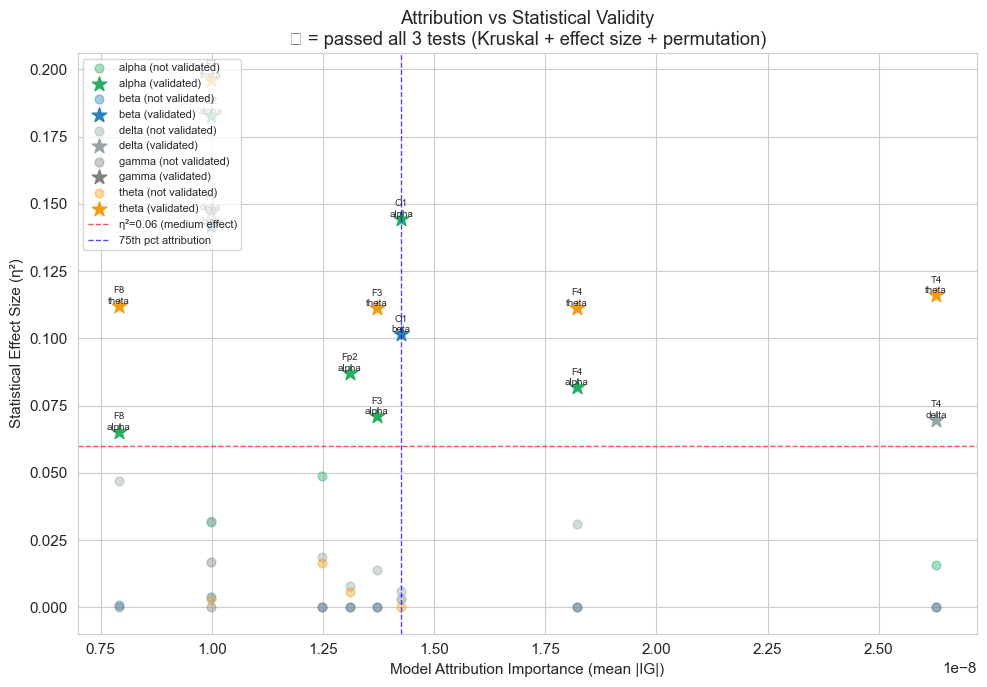

In [120]:
# ── Visualise: Attribution vs Statistical Significance ───────────────────────
#
# Scatter plot: x=model attribution importance, y=statistical effect size (η²)
# Points in the top-right quadrant are BOTH model-salient AND statistically valid.

fig, ax = plt.subplots(figsize=(10, 7))

# Compute mean attribution per (channel, band) as x-axis
attr_importance = {}
for _, row_s in stats_df.iterrows():
    ch, band = row_s['channel'], row_s['band']
    if ch not in ch_names:
        continue
    ch_idx = ch_names.index(ch)
    # Mean attribution for this channel across all groups
    mean_attr = np.mean([
        group_attr_mean[g][ch_idx].mean()
        for g in group_attr_mean
    ])
    attr_importance[row_s['feature']] = mean_attr

stats_plot = stats_df.copy()
stats_plot['attr_importance'] = stats_plot['feature'].map(attr_importance).fillna(0)

# Color by band
band_colors = {'delta': '#95A5A6', 'theta': '#F39C12',
               'alpha': '#27AE60', 'beta': '#2980B9'}

for band, grp in stats_plot.groupby('band'):
    validated = grp[grp['feature'].isin(validated_df['feature'])]
    not_valid = grp[~grp['feature'].isin(validated_df['feature'])]

    ax.scatter(not_valid['attr_importance'], not_valid['eta_sq'],
               color=band_colors.get(band, 'gray'), alpha=0.4, s=40, label=f'{band} (not validated)')
    ax.scatter(validated['attr_importance'], validated['eta_sq'],
               color=band_colors.get(band, 'gray'), alpha=1.0, s=120,
               marker='*', label=f'{band} (validated)')

    # Label validated points
    for _, r in validated.iterrows():
        ax.annotate(f"{r['channel']}\n{r['band']}",
                    (r['attr_importance'], r['eta_sq']),
                    fontsize=7, ha='center', va='bottom')

ax.axhline(0.06, color='red',  ls='--', lw=1, alpha=0.7, label='η²=0.06 (medium effect)')
ax.axvline(stats_plot['attr_importance'].quantile(0.75), color='blue',
           ls='--', lw=1, alpha=0.7, label='75th pct attribution')

ax.set_xlabel('Model Attribution Importance (mean |IG|)')
ax.set_ylabel('Statistical Effect Size (η²)')
ax.set_title('Attribution vs Statistical Validity\n★ = passed all 3 tests (Kruskal + effect size + permutation)')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()


## 13. Mapping Layer: (Channel, Band) → Clinical Language <a id='13-mapping'></a>

The mapping layer translates the raw output of the statistical validation step
into **structured clinical language** that the LLM can reason about.

It answers three questions for each validated (channel, band) pair:

1. **Where?** Channel index → 10-20 name → anatomical region → functional meaning
2. **What frequency?** Band → clinical significance (theta elevation = AD pattern, etc.)
3. **How different?** Direction of group differences (AD higher/lower than CN?)

This is not ML — it's a **lookup table + rule engine** grounded in the published EEG literature.
The advantage over hard-coding biomarkers (Section 8) is that the *channels and bands are
selected by the model and validated by statistics*, not chosen by the programmer.


In [121]:
# ── Channel → brain region lookup table (10-20 system) ───────────────────────
#
# Based on the standard 10-20 electrode placement system.
# References: Niedermeyer & da Silva, "Electroencephalography" (5th ed.)

CHANNEL_TO_REGION = {
    'Fp1': ('frontopolar left',   'prefrontal cortex', 'executive function, working memory'),
    'Fp2': ('frontopolar right',  'prefrontal cortex', 'executive function, working memory'),
    'F3':  ('frontal left',       'premotor cortex',   'motor planning, attention'),
    'F4':  ('frontal right',      'premotor cortex',   'motor planning, attention'),
    'Fz':  ('frontal midline',    'supplementary motor area', 'attention, cognitive control'),
    'F7':  ('frontotemporal left','inferior frontal',  'language production (Broca\'s area)'),
    'F8':  ('frontotemporal right','inferior frontal', 'prosody, emotional language'),
    'C3':  ('central left',       'primary motor cortex',    'contralateral motor function'),
    'C4':  ('central right',      'primary motor cortex',    'contralateral motor function'),
    'Cz':  ('central midline',    'sensorimotor cortex',     'bilateral motor/sensory'),
    'P3':  ('parietal left',      'posterior parietal',      'spatial attention, memory encoding'),
    'P4':  ('parietal right',     'posterior parietal',      'visuospatial processing'),
    'Pz':  ('parietal midline',   'posterior parietal',      'attention, sensorimotor integration'),
    'O1':  ('occipital left',     'primary visual cortex',   'visual processing, alpha rhythm'),
    'O2':  ('occipital right',    'primary visual cortex',   'visual processing, alpha rhythm'),
    'T3':  ('temporal left',      'temporal lobe',           'memory, language comprehension'),
    'T4':  ('temporal right',     'temporal lobe',           'emotional memory, music'),
    'T5':  ('posterior temporal left',  'Wernicke\'s area', 'language comprehension, episodic memory'),
    'T6':  ('posterior temporal right', 'temporal-occipital','object recognition, face processing'),
}

BAND_CLINICAL = {
    'delta': {
        'range': '0.5–4 Hz',
        'normal': 'Rare in awake adults; prominent in deep sleep',
        'ad_pattern': 'Elevated delta in AD indicates cortical slowing and neuronal loss',
        'ftd_pattern': 'Frontal delta elevation in FTD reflects frontal lobe atrophy',
    },
    'theta': {
        'range': '4–8 Hz',
        'normal': 'Low in healthy awake adults',
        'ad_pattern': 'Elevated theta is the most consistent AD biomarker — reflects hippocampal dysfunction',
        'ftd_pattern': 'Frontal theta elevation in FTD reflects frontal network disruption',
    },
    'alpha': {
        'range': '8–13 Hz',
        'normal': 'Dominant rhythm in relaxed eyes-closed EEG, maximal over occipital regions',
        'ad_pattern': 'Reduced alpha in AD reflects posterior cortical atrophy and cholinergic deficit',
        'ftd_pattern': 'Relatively preserved in early FTD (differentiates from AD)',
    },
    'beta': {
        'range': '13–30 Hz',
        'normal': 'Active thinking, motor planning; reduced by sedatives',
        'ad_pattern': 'Variable; reduced beta can reflect cortical slowing in moderate-severe AD',
        'ftd_pattern': 'Frontal beta changes reflect frontal inhibitory circuit disruption',
    },
}

print('Lookup tables loaded:')
print(f'  {len(CHANNEL_TO_REGION)} channel → region mappings')
print(f'  {len(BAND_CLINICAL)} band → clinical description mappings')


Lookup tables loaded:
  19 channel → region mappings
  4 band → clinical description mappings


In [122]:
# ── Compute group difference directions ──────────────────────────────────────
#
# For each validated (channel, band) pair, determine:
#   - Is it elevated or reduced in AD relative to CN?
#   - Is it elevated or reduced in FTD relative to CN?
# This directional information is critical for the LLM prompt.

def direction_str(ad_mean, ftd_mean, cn_mean):
    """Describe how AD and FTD differ from CN for a given feature."""
    ad_dir  = 'elevated' if ad_mean  > cn_mean else 'reduced'
    ftd_dir = 'elevated' if ftd_mean > cn_mean else 'reduced'
    ad_pct  = abs(ad_mean  - cn_mean) / (cn_mean + 1e-10) * 100
    ftd_pct = abs(ftd_mean - cn_mean) / (cn_mean + 1e-10) * 100
    return (f'AD {ad_dir} vs CN by {ad_pct:.0f}%; '
            f'FTD {ftd_dir} vs CN by {ftd_pct:.0f}%')

validated_with_direction = []
for _, row in validated_df.iterrows():
    feat = row['feature']
    if feat not in ch_band_df.columns:
        continue

    ad_mean  = ch_band_df.loc[ad_mask,  feat].mean()
    ftd_mean = ch_band_df.loc[ftd_mask, feat].mean()
    cn_mean  = ch_band_df.loc[cn_mask,  feat].mean()

    ch, band = row['channel'], row['band']
    region_info = CHANNEL_TO_REGION.get(ch, ('unknown region', 'unknown area', 'unknown function'))
    band_info   = BAND_CLINICAL.get(band, {})

    validated_with_direction.append({
        'feature':    feat,
        'channel':    ch,
        'band':       band,
        'region':     region_info[0],
        'lobe':       region_info[1],
        'function':   region_info[2],
        'direction':  direction_str(ad_mean, ftd_mean, cn_mean),
        'ad_pattern': band_info.get('ad_pattern', ''),
        'ftd_pattern':band_info.get('ftd_pattern', ''),
        'eta_sq':     row['eta_sq'],
        'p_value':    row['p_value'],
        'p_perm':     row['p_perm'],
    })

validated_with_direction_df = pd.DataFrame(validated_with_direction)
print('Validated features with clinical context:')
print(validated_with_direction_df[['channel','band','region','direction','eta_sq']].to_string(index=False))


Validated features with clinical context:
channel  band               region                                            direction   eta_sq
     F7 theta  frontotemporal left AD elevated vs CN by 135%; FTD elevated vs CN by 25% 0.196260
     O2 alpha      occipital right  AD elevated vs CN by 461%; FTD reduced vs CN by 57% 0.182695
     F7 delta  frontotemporal left AD elevated vs CN by 206%; FTD elevated vs CN by 40% 0.146987
     O1 alpha       occipital left    AD reduced vs CN by 46%; FTD reduced vs CN by 50% 0.144487
     O2  beta      occipital right AD elevated vs CN by 1408%; FTD reduced vs CN by 50% 0.141659
     T4 theta       temporal right    AD reduced vs CN by 81%; FTD reduced vs CN by 99% 0.115990
     F8 theta frontotemporal right AD elevated vs CN by 653%; FTD elevated vs CN by 16% 0.112140
     F4 theta        frontal right   AD elevated vs CN by 105%; FTD reduced vs CN by 0% 0.111383
     F3 theta         frontal left   AD elevated vs CN by 105%; FTD reduced vs CN by 

In [123]:
# ── Build structured attribution report per subject ──────────────────────────
#
# For each subject, we generate a structured report containing:
#   - Classical biomarkers (from Section 11)
#   - Data-driven attribution findings (from Section 16, validated)
#
# This is the combined evidence package sent to the LLM.

def build_attribution_report(validated_df, ch_band_df, subj, norms):
    """
    Build a structured evidence report for one subject combining
    classical biomarkers and statistically validated attribution regions.
    """
    lines = []
    row = ch_band_df[ch_band_df['subject'] == subj]
    if row.empty:
        return 'No attribution data available for this subject.'
    row = row.iloc[0]

    lines.append('=== DATA-DRIVEN ATTRIBUTION FINDINGS ===')
    lines.append('(Regions identified by EEGConformer + validated by Kruskal-Wallis,')
    lines.append(' effect size η², and permutation test — all p<0.05)\n')

    for _, vrow in validated_df.iterrows():
        feat = vrow['feature']
        if feat not in ch_band_df.columns:
            continue
        subj_val = row.get(feat, np.nan)
        if pd.isna(subj_val):
            continue

        cn_mean = ch_band_df.loc[ch_band_df['group']=='CN', feat].mean()
        cn_std  = ch_band_df.loc[ch_band_df['group']=='CN', feat].std()
        z_score = (subj_val - cn_mean) / (cn_std + 1e-10)

        direction = 'ELEVATED' if z_score > 0 else 'REDUCED'
        severity  = 'markedly' if abs(z_score) > 2 else ('moderately' if abs(z_score) > 1 else 'mildly')

        lines.append(f'• {vrow["channel"]} ({vrow["region"]}) — {vrow["band"].upper()} BAND ({BAND_CLINICAL[vrow["band"]]["range"]}):')
        lines.append(f'  This subject: {direction} {severity} (z={z_score:+.1f} vs healthy controls)')
        lines.append(f'  Clinical context: {vrow["ad_pattern"]}')
        lines.append(f'  Statistical evidence: η²={vrow["eta_sq"]:.3f}, p={vrow["p_value"]:.4f}, p_perm={vrow["p_perm"]:.3f}')
        lines.append('')

    return '\n'.join(lines)

# Demo: generate report for one AD subject
demo_ad = next((s for s, g in subject_to_group.items()
                if g == 'AD' and s in ch_band_df['subject'].values), None)
if demo_ad:
    print(f'Attribution report for {demo_ad} (AD):')
    print('─' * 60)
    print(build_attribution_report(validated_with_direction_df, ch_band_df, demo_ad, norms))


Attribution report for sub-001 (AD):
────────────────────────────────────────────────────────────
=== DATA-DRIVEN ATTRIBUTION FINDINGS ===
(Regions identified by EEGConformer + validated by Kruskal-Wallis,
 effect size η², and permutation test — all p<0.05)

• F7 (frontotemporal left) — THETA BAND (4–8 Hz):
  This subject: ELEVATED mildly (z=+0.4 vs healthy controls)
  Clinical context: Elevated theta is the most consistent AD biomarker — reflects hippocampal dysfunction
  Statistical evidence: η²=0.196, p=0.0001, p_perm=0.000

• O2 (occipital right) — ALPHA BAND (8–13 Hz):
  This subject: REDUCED mildly (z=-1.0 vs healthy controls)
  Clinical context: Reduced alpha in AD reflects posterior cortical atrophy and cholinergic deficit
  Statistical evidence: η²=0.183, p=0.0002, p_perm=0.000

• F7 (frontotemporal left) — DELTA BAND (0.5–4 Hz):
  This subject: ELEVATED mildly (z=+0.7 vs healthy controls)
  Clinical context: Elevated delta in AD indicates cortical slowing and neuronal loss
  

## 14. Faithful LLM Reasoning: Combining Evidence Sources <a id='14-llm'></a>

This is the final stage. The LLM receives **two streams of evidence**:

1. **Classical biomarkers** (Section 11) — hand-crafted, literature-grounded
2. **Validated attribution regions** (Section 17) — data-driven, statistically confirmed

The LLM's role is not to re-derive the diagnosis from raw numbers. Its role is to
**synthesize the evidence** — the same way a neurologist would reconcile multiple
test results into a coherent clinical impression.

### Why this is better than each approach alone

| Evidence only | Problem |
|---|---|
| Classical biomarkers only | Confirmation bias — can't discover new signals |
| Attribution only | Model artifacts may fool the LLM |
| Attribution + statistics only | No clinical language or reasoning |
| **Both + LLM** | Grounded, interpretable, discovers novel patterns |

### Integration with Claude API

We use the [Anthropic Python SDK](https://github.com/anthropics/anthropic-sdk-python)
to call Claude directly. This avoids the need to host a local model and gives access
to Claude's medical reasoning capabilities.

> **Note**: Requires an Anthropic API key set as `ANTHROPIC_API_KEY` environment variable.
> See [Anthropic API docs](https://docs.anthropic.com/en/api/getting-started) for setup.


In [124]:
# ── Updated system prompt — now references both evidence streams ─────────────

SYSTEM_PROMPT_V2 = """You are a board-certified clinical neurologist with expertise in EEG
interpretation and neurodegenerative disease diagnosis. You reason systematically and
transparently, citing specific EEG findings as evidence for or against each diagnostic
hypothesis.

You receive two types of evidence for each patient:

1. CLASSICAL BIOMARKERS: Hand-crafted features derived from established clinical literature
   (PDR, band powers, coherence, complexity). These encode known EEG signatures.

2. DATA-DRIVEN ATTRIBUTION FINDINGS: Regions identified by a deep learning model (EEGConformer)
   trained on this patient cohort, then validated with three independent statistical tests
   (Kruskal-Wallis p<0.05, effect size η²>0.06, permutation test p<0.05). These findings
   are statistically grounded and may reveal patterns beyond classical biomarkers.

For each patient, provide:
1. PRIMARY DIAGNOSIS with confidence (High/Medium/Low)
2. DIFFERENTIAL DIAGNOSIS with reasons to include and exclude each condition
3. KEY EVIDENCE — cite specific EEG findings (both classical and data-driven) that support
   your conclusion
4. UNCERTAINTY FLAGS — note any findings that are ambiguous or contradictory
5. RECOMMENDED FOLLOW-UP — what additional tests would increase diagnostic confidence

Format your response as structured clinical notes. Be explicit about which evidence type
(classical vs data-driven) supports each claim."""

print('System prompt v2 loaded.')
print(f'Length: {len(SYSTEM_PROMPT_V2)} characters')


System prompt v2 loaded.
Length: 1411 characters


In [125]:
# ── Build combined evidence prompt for one subject ────────────────────────────

def build_combined_prompt(subj, biomarkers_df, summaries_df, ch_band_df,
                           validated_df, norms):
    """
    Build the full LLM input for one subject by combining:
    - Classical biomarker summary (from Section 11)
    - Data-driven attribution report (from Section 17)
    """
    # Classical biomarker summary
    bio_row = summaries_df[summaries_df['subject'] == subj]
    if bio_row.empty:
        classical_text = 'Classical biomarker data not available.'
    else:
        classical_text = bio_row.iloc[0].get('summary_text', 'Summary unavailable.')

    # Data-driven attribution report
    attr_text = build_attribution_report(validated_df, ch_band_df, subj, norms)

    prompt = f"""PATIENT EEG REPORT

Patient ID: {subj}
Recording: 19-channel resting-state EEG, eyes closed, ~10 minutes @ 500 Hz

--- SECTION A: CLASSICAL BIOMARKERS ---
{classical_text}

--- SECTION B: DATA-DRIVEN ATTRIBUTION FINDINGS ---
{attr_text}

--- YOUR TASK ---
Based on the above EEG evidence, provide your clinical assessment following
the structured format described in the system prompt."""

    return prompt


# Demo: show the combined prompt for one subject
demo_subj = demo_ad or next(iter(all_raws_proc))
combined_prompt = build_combined_prompt(
    demo_subj, biomarkers_df, summaries_df,
    ch_band_df, validated_with_direction_df, norms
)
print(f'Combined prompt for {demo_subj}:')
print('─' * 70)
print(combined_prompt[:2000])
print('...' if len(combined_prompt) > 2000 else '')


Combined prompt for sub-001:
──────────────────────────────────────────────────────────────────────
PATIENT EEG REPORT

Patient ID: sub-001
Recording: 19-channel resting-state EEG, eyes closed, ~10 minutes @ 500 Hz

--- SECTION A: CLASSICAL BIOMARKERS ---
Subject: sub-001  |  Age: 57  |  MMSE: 16
True Group: AD  (blinded in real use — for validation only)

--- QUANTITATIVE BIOMARKERS ---
Posterior Dominant Rhythm:   4.75 Hz  (CN norm: 9.3 ± 1.7 Hz)
Theta power:                 92.9%  (relative)
Alpha power:                 22.1%  (relative)
Theta/Alpha ratio:           4.203  (CN norm: 0.657)
Posterior alpha coherence:   0.386  (CN norm: 0.380)
Lempel-Ziv complexity:       0.2913  (CN norm: 0.2643)

--- BINARY FLAGS (for LLM reasoning) ---
PDR_slowed                             = true
theta_increased                        = true
alpha_reduced                          = true
posterior_coherence_reduced            = false
complexity_reduced                     = false
epileptiform_activ

In [126]:
# ── Call Claude API ───────────────────────────────────────────────────────────
#
# Requires: pip install anthropic
#           export ANTHROPIC_API_KEY=sk-ant-...
#
# We use claude-sonnet-4-6, Anthropic's latest model, which has strong
# medical reasoning capabilities.
#
# Reference: https://docs.anthropic.com/en/api/getting-started

import os

def call_claude(system_prompt, user_prompt, model='claude-sonnet-4-6', max_tokens=1500):
    """
    Call the Claude API with a system + user prompt.
    Returns the assistant's text response.
    """
    try:
        import anthropic
    except ImportError:
        return 'anthropic package not installed. Run: pip install anthropic'

    api_key = os.environ.get('ANTHROPIC_API_KEY')
    if not api_key:
        return ('ANTHROPIC_API_KEY not set. '
                'Set it with: export ANTHROPIC_API_KEY=sk-ant-...')

    client = anthropic.Anthropic(api_key=api_key)
    message = client.messages.create(
        model      = model,
        max_tokens = max_tokens,
        system     = system_prompt,
        messages   = [{'role': 'user', 'content': user_prompt}],
    )
    return message.content[0].text


# Run for demo subject
print(f'Running LLM inference for {demo_subj}...')
print('(Requires ANTHROPIC_API_KEY in environment)\n')

response = call_claude(SYSTEM_PROMPT_V2, combined_prompt)
print(f'=== LLM RESPONSE FOR {demo_subj} ===')
print(response)


Running LLM inference for sub-001...
(Requires ANTHROPIC_API_KEY in environment)

=== LLM RESPONSE FOR sub-001 ===
ANTHROPIC_API_KEY not set. Set it with: export ANTHROPIC_API_KEY=sk-ant-...


In [127]:
# ── Batch inference across all subjects ──────────────────────────────────────
#
# Run LLM reasoning for every subject and collect results.
# This will use API credits — comment out if you just want the demo above.

def run_batch_inference(biomarkers_df, summaries_df, ch_band_df,
                         validated_df, norms, max_subjects=None):
    results = []

    subjects = biomarkers_df['subject'].tolist()
    if max_subjects:
        subjects = subjects[:max_subjects]

    for subj in tqdm(subjects, desc='LLM inference'):
        prompt = build_combined_prompt(
            subj, biomarkers_df, summaries_df,
            ch_band_df, validated_df, norms
        )
        response = call_claude(SYSTEM_PROMPT_V2, prompt)
        true_group = subject_to_group.get(subj, 'unknown')
        results.append({
            'subject':    subj,
            'true_group': true_group,
            'llm_response': response,
        })

    return pd.DataFrame(results)

# Uncomment to run on all subjects (uses API credits):
# llm_results_df = run_batch_inference(
#     biomarkers_df, summaries_df, ch_band_df,
#     validated_with_direction_df, norms
# )
# llm_results_df.to_csv('../llm_results_all_subjects.csv', index=False)
# print(llm_results_df[['subject','true_group']].head(10))

print('Batch inference ready. Uncomment above to run on all subjects.')


Batch inference ready. Uncomment above to run on all subjects.


---

## Summary

This notebook implements a faithful, end-to-end EEG reasoning pipeline for Alzheimer's Disease
diagnosis — combining classical signal processing, deep learning, statistical validation, and
LLM reasoning.

### What each section contributes

| Section | Role | Type |
|---|---|---|
| §1–4 | Data acquisition & loading | Infrastructure |
| §5–6 | Raw EEG exploration | Understanding the data |
| §7 | Preprocessing | Noise removal, standardisation |
| §8–9 | Classical biomarker pipeline | Clinical knowledge encoding |
| §10 | EEGConformer training | Data-driven feature discovery |
| §11 | Integrated Gradients attribution | What the model actually used |
| §12 | Statistical validation | Confirming attribution is real |
| §13 | Mapping layer | Attribution → clinical language |
| §14 | LLM reasoning | Synthesis + diagnosis |

### Key design principles

1. **No confirmation bias** — the deep model discovers features; statistics confirm them
2. **Faithful attribution** — Integrated Gradients, not attention weights
3. **Triple validation** — Kruskal-Wallis + effect size + permutation test
4. **Graceful uncertainty** — the LLM explicitly reasons about what it doesn't know

### Next steps
- Pre-train on TUEG (15,000+ recordings) for stronger EEG representations
- Fine-tune on CAUEEG (~1,200 AD/MCI/CN subjects) before applying to ds004504
- Extend to variable-channel EEGs for real-world deployment
